# Quantum Tilted Loss in QAOA and HEA for MaxCut

This notebook explores the performance of the **Quantum Tilted Loss Function** in solving the MaxCut problem using the **Quantum Approximate Optimization Algorithm (QAOA)** and a **Hardware Efficient Ansatz (HEA)**.

### 1. Mathematical Background
The standard loss function in VQA is the expectation value of the Hamiltonian:
$$\mathcal{L}_{std}(\theta) = \bra{\psi(\theta)} H \ket{\psi(\theta)}$$

The **Quantum Tilted Loss Function** is defined as:
$$\mathcal{L}_\gamma(H,\rho(\theta)) := - \frac{1}{\gamma} \log \text{tr} \left( e^{- \gamma H} \rho(\theta) \right)$$
where $\gamma$ is a real parameter. As $\gamma \to 0$, it recovers the standard expectation value. For $\gamma > 0$, it penalizes high-energy (sub-optimal) states more heavily, potentially accelerating convergence to the ground state.

### 2. Goal
1. Compare Standard Loss vs Tilted Loss for MaxCut with QAOA.
2. Test Tilted Loss with Hardware Efficient Ansatz.
3. Compare the algorithm performance with different fixed values of $\gamma$ (0.1, 5, 10, 20, 100).
4. Investigate the effect of tuning $\gamma$ using different schedules (Linear, Sigmoid, Exponential, Logarithmic).

In [ ]:
%%capture

# Comment this out if you don't want to install pennylane from this notebook
!pip install pennylane

# Comment this out if you don't want to install matplotlib from this notebook
!pip install matplotlib

In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time
import math
from dataclasses import dataclass

from IPython.display import display
import pennylane as qml

import networkx as nx

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)

In [101]:
@dataclass(frozen=True)
class ObjectiveSpec:
    name: str
    kind: str
    alpha: float | None = None
    gamma: float | None = None
    gamma_start: float | None = None
    gamma_end: float | None = None
    schedule: str | None = None
    color: str = "C0"


MAIN_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("CVaR 0.2", "cvar", alpha=0.2, color="#ff7f0e"),
    ObjectiveSpec("QTL gamma=5.0", "qtl", gamma=5.0, color="#2ca02c"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="linear",
        color="#9467bd",
    ),
]

SCHEDULE_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="linear",
        color="#9467bd",
    ),
    ObjectiveSpec(
        "QTL schedule sigmoid",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="sigmoid",
        color="#e377c2",
    ),
    ObjectiveSpec(
        "QTL reverse linear",
        "qtl_schedule",
        gamma_start=200,
        gamma_end=0.25,
        schedule="linear",
        color="#7f7f7f",
    ),
]

FIXED_GAMMA_GRID = [0.5, 5, 20, 100, 200]
GAMMA_GRID_OBJECTIVES = [
    ObjectiveSpec(f"QTL gamma={gamma}", "qtl", gamma=gamma, color=plt.cm.viridis(i / (len(FIXED_GAMMA_GRID) - 1)))
    for i, gamma in enumerate(FIXED_GAMMA_GRID)
] + [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("CVaR 0.2", "cvar", alpha=0.2, color="#ff7f0e"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="linear",
        color="#9467bd",
    ),
]

CURVE_OBJECTIVES = ["Expectation", "CVaR 0.2", "QTL gamma=5.0", "QTL gamma=20.0", "QTL schedule linear"]
HARD_OBJECTIVES = ["Expectation", "CVaR 0.2", "QTL gamma=20.0", "QTL schedule linear"]
BUDGET_OBJECTIVES = ["Expectation", "CVaR 0.2", "QTL gamma=20.0", "QTL schedule linear"]

ALL_OBJECTIVES = {
    obj.name: obj
    for obj in MAIN_OBJECTIVES + SCHEDULE_OBJECTIVES + GAMMA_GRID_OBJECTIVES
}
OBJECTIVE_COLORS = {name: obj.color for name, obj in ALL_OBJECTIVES.items()}

FAST_CONFIG = {
    # "graph_families": ["regular3"],
    "graph_families": ["erdos_renyi"],
    "sizes": [14],
    # "sizes": [8, 10, 12],
    # "depths": [1, 2, 3],
    "depths": [3],
    "seeds": [0, 1, 2],
    "steps": 300,
    "shots": 1024,
    "gradient_probes": 4,
    "target_ratio": 0.99,
    "curve_n": 14,
    "summary_n": 14,
    "summary_p": 3,
    "budget_n": 14,
    "budget_p": 3,
    "budget_seeds": [0, 1, 2],
    "budget_shots_grid": [64, 128, 256, 512],
    "budget_total_shots": 15360,
    "gamma_grid_n": 14,
    "gamma_grid_p": 3,
    "schedule_n": 14,
    "schedule_p": 3,
}

FULL_CONFIG = {
    **FAST_CONFIG,
    "graph_families": ["erdos_renyi"],
    # "graph_families": ["regular3", "erdos_renyi"],
    "seeds": list(range(8)),
    "steps": 300,
    "shots": 1024,
    "gradient_probes": 8,
    "budget_seeds": list(range(8)),
}

RUN_CONFIG = FAST_CONFIG
print("Running config:", RUN_CONFIG)


Running config: {'graph_families': ['erdos_renyi'], 'sizes': [14], 'depths': [3], 'seeds': [0, 1, 2], 'steps': 300, 'shots': 1024, 'gradient_probes': 4, 'target_ratio': 0.99, 'curve_n': 14, 'summary_n': 14, 'summary_p': 3, 'budget_n': 14, 'budget_p': 3, 'budget_seeds': [0, 1, 2], 'budget_shots_grid': [64, 128, 256, 512], 'budget_total_shots': 15360, 'gamma_grid_n': 14, 'gamma_grid_p': 3, 'schedule_n': 14, 'schedule_p': 3}


## Task 1: QAOA Comparison (Standard vs CVaR vs Tilted)

We calculate the exact maximum cuts of the graphs using brute force sampling search, which is denoted by $c_{max}$. Then we use QAOA algorithm to solve the maxcut problem and return us with the final bit string that corresponds to a cut $c_{obtained}$. Then we evaluate the approximation ratio of this obtained cut compared to the exact maximum cut, and plot the figure.

In [77]:
# Code to generate the graph
def make_graph(n, family, seed):
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        p = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, p, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, p, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph


def basis_states(n):
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)


def cut_values_from_samples(samples, edges):
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts


def exact_cut_data(n, edges):
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())

[(0, 3), (0, 4), (0, 12), (1, 9), (1, 10), (2, 7), (2, 9), (2, 13), (3, 13), (5, 13), (6, 9), (8, 10), (9, 10), (10, 11), (10, 13), (12, 13)]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
[0. 5. 2. ... 2. 5. 0.]
15.0


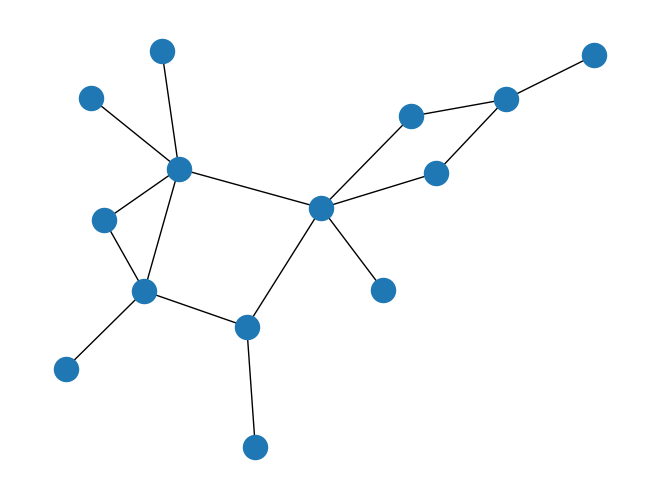

In [75]:
n = 14
family = 'erdos_renyi'
# Set random seed for reproducibility
# seed = np.random.seed(42)
G = make_graph(n, family, 1)
nx.draw(G)

edges = sorted(G.edges())
print(edges)

a,b,c = exact_cut_data(n, edges)
print(a)
print(b)
print(c)

Define the Hamiltonian

In [76]:
# # Define a small graph for MaxCut (4-node ring)
# nodes = 4
# edges = [(0, 1), (1, 2), (2, 3), (3, 0)]


# Hamiltonian: H = sum 0.5 * (Zi * Zj - 1) for (i,j) in edges
# Minimizing this minimizes edges with same spin, thus maximizing the cut.
coeffs = [0.5] * len(edges) + [-0.5] * len(edges)
obs = [qml.PauliZ(i) @ qml.PauliZ(j) for i, j in edges] + [qml.Identity(i) for i in range(len(edges))]
H = qml.Hamiltonian(coeffs, obs)

print(f'Hamiltonian for {n}-node MaxCut:\n', H)

Hamiltonian for 14-node MaxCut:
 0.5 * (Z(0) @ Z(3)) + 0.5 * (Z(0) @ Z(4)) + 0.5 * (Z(0) @ Z(12)) + 0.5 * (Z(1) @ Z(9)) + 0.5 * (Z(1) @ Z(10)) + 0.5 * (Z(2) @ Z(7)) + 0.5 * (Z(2) @ Z(9)) + 0.5 * (Z(2) @ Z(13)) + 0.5 * (Z(3) @ Z(13)) + 0.5 * (Z(5) @ Z(13)) + 0.5 * (Z(6) @ Z(9)) + 0.5 * (Z(8) @ Z(10)) + 0.5 * (Z(9) @ Z(10)) + 0.5 * (Z(10) @ Z(11)) + 0.5 * (Z(10) @ Z(13)) + 0.5 * (Z(12) @ Z(13)) + -0.5 * I(0) + -0.5 * I(1) + -0.5 * I(2) + -0.5 * I(3) + -0.5 * I(4) + -0.5 * I(5) + -0.5 * I(6) + -0.5 * I(7) + -0.5 * I(8) + -0.5 * I(9) + -0.5 * I(10) + -0.5 * I(11) + -0.5 * I(12) + -0.5 * I(13) + -0.5 * I(14) + -0.5 * I(15)


Define the loss functions.

In [78]:
def cvar_loss(losses, alpha):
    k = max(1, int(math.ceil(alpha * len(losses))))
    return float(np.mean(np.partition(losses, k - 1)[:k]))


def qtl_loss(losses, gamma):
    losses = np.asarray(losses, dtype=float)
    if gamma is None or abs(gamma) < 1e-12:
        return float(np.mean(losses))
    loss_min = float(losses.min())
    shifted = losses - loss_min
    return float(loss_min - np.log(np.mean(np.exp(-gamma * shifted))) / gamma)


def qtl_loss_from_distribution(probs, losses, gamma):
    probs = np.asarray(probs, dtype=float)
    losses = np.asarray(losses, dtype=float)
    if gamma is None or abs(gamma) < 1e-12:
        return float(np.dot(probs, losses))
    loss_min = float(losses.min())
    shifted = losses - loss_min
    return float(loss_min - np.log(np.dot(probs, np.exp(-gamma * shifted))) / gamma)


def _sigmoid_frac(frac):
    base = 1.0 / (1.0 + np.exp(-12.0 * (frac - 0.5)))
    low = 1.0 / (1.0 + np.exp(6.0))
    high = 1.0 / (1.0 + np.exp(-6.0))
    return float((base - low) / (high - low))


def scheduled_gamma(spec, step, total_steps):
    if spec.kind != "qtl_schedule":
        return spec.gamma
    if total_steps <= 1:
        return float(spec.gamma_end)
    frac = step / (total_steps - 1)
    if spec.schedule == "linear":
        schedule_frac = frac
    elif spec.schedule == "sigmoid":
        schedule_frac = _sigmoid_frac(frac)
    elif spec.schedule == "piecewise":
        if frac < 0.5:
            schedule_frac = 0.2 * frac / 0.5
        else:
            schedule_frac = 0.2 + 0.8 * (frac - 0.5) / 0.5
    else:
        raise ValueError(f"Unknown schedule: {spec.schedule}")
    return float(spec.gamma_start + schedule_frac * (spec.gamma_end - spec.gamma_start))


def sampled_loss(cuts, c_max, spec, step, total_steps):
    losses = c_max - np.asarray(cuts, dtype=float)
    if spec.kind == "expectation":
        return float(np.mean(losses)), np.nan
    if spec.kind == "cvar":
        return cvar_loss(losses, spec.alpha), np.nan
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss(losses, gamma), gamma


def exact_loss_from_distribution(probs, cuts, c_max, spec, step, total_steps):
    losses = c_max - cuts
    if spec.kind == "expectation":
        return float(np.dot(probs, losses)), np.nan
    if spec.kind == "cvar":
        # Exact CVaR is not needed for the landscape demo in this notebook.
        raise ValueError("Exact CVaR objective is not implemented here.")
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss_from_distribution(probs, losses, gamma), gamma

Define the QAOA circuit, sampler, and optimizer.

In [ ]:
def make_qaoa_sampler(n, edges, shots, device_seed):
    dev = qml.device("default.qubit", wires=n, seed=int(device_seed))

    @qml.set_shots(shots)
    @qml.qnode(dev, diff_method=None)
    def circuit(params):
        p = len(params) // 2
        gammas = params[:p]
        betas = params[p:]
        for wire in range(n):
            qml.Hadamard(wires=wire)
        for gamma, beta in zip(gammas, betas):
            for u, v in edges:
                qml.IsingZZ(2.0 * gamma, wires=[u, v])
            for wire in range(n):
                qml.RX(2.0 * beta, wires=wire)
        return qml.sample(wires=range(n))

    return circuit


def make_exact_qaoa_probs(n, edges):
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev, diff_method=None)
    def circuit(params):
        p = len(params) // 2
        gammas = params[:p]
        betas = params[p:]
        for wire in range(n):
            qml.Hadamard(wires=wire)
        for gamma, beta in zip(gammas, betas):
            for u, v in edges:
                qml.IsingZZ(2.0 * gamma, wires=[u, v])
            for wire in range(n):
                qml.RX(2.0 * beta, wires=wire)
        return qml.probs(wires=range(n))

    return circuit


def make_evaluator(n, edges, c_max, shots, spec, total_steps, device_seed):
    sampler = make_qaoa_sampler(n, edges, shots, device_seed=device_seed)

    def evaluate(params, step):
        params = np.asarray(params, dtype=float)
        wrapped = np.mod(params, 2 * np.pi)
        samples = np.asarray(sampler(wrapped), dtype=int)
        cuts = cut_values_from_samples(samples, edges)
        loss, gamma = sampled_loss(cuts, c_max, spec, step, total_steps)
        return loss, {
            "mean_cut": float(np.mean(cuts)),
            "best_cut": int(np.max(cuts)),
            "mean_ratio": float(np.mean(cuts) / c_max),
            "best_ratio": float(np.max(cuts) / c_max),
            "c_max": float(c_max),
            "gamma": gamma,
        }

    return evaluate


def estimate_initial_statistics(evaluate, init_params, probes, rng, epsilon=0.15):
    if probes <= 0:
        return {
            "grad_norm_mean": np.nan,
            "grad_norm_var": np.nan,
            "objective_var": np.nan,
        }
    norms = []
    values = []
    for _ in range(probes):
        delta = rng.choice([-1.0, 1.0], size=len(init_params))
        loss_plus, _ = evaluate(init_params + epsilon * delta, step=0)
        loss_minus, _ = evaluate(init_params - epsilon * delta, step=0)
        grad = (loss_plus - loss_minus) / (2.0 * epsilon) * delta
        norms.append(np.linalg.norm(grad))
        values.extend([loss_plus, loss_minus])
    return {
        "grad_norm_mean": float(np.mean(norms)),
        "grad_norm_var": float(np.var(norms)),
        "objective_var": float(np.var(values)),
    }


def spsa_optimize(evaluate, init_params, steps, shots, rng, a=0.18, c=0.12, A=8.0):
    params = np.asarray(init_params, dtype=float).copy()
    best_cut_so_far = -np.inf
    history = []

    for step in range(steps):
        delta = rng.choice([-1.0, 1.0], size=len(params))
        ck = c / ((step + 1) ** 0.101)
        ak = a / ((step + 1 + A) ** 0.602)

        loss_plus, plus_metrics = evaluate(params + ck * delta, step)
        loss_minus, minus_metrics = evaluate(params - ck * delta, step)
        grad = (loss_plus - loss_minus) / (2.0 * ck) * delta

        params = np.mod(params - ak * grad, 2 * np.pi)
        loss_cur, cur_metrics = evaluate(params, step)

        best_cut_so_far = max(
            best_cut_so_far,
            plus_metrics["best_cut"],
            minus_metrics["best_cut"],
            cur_metrics["best_cut"],
        )

        history.append(
            {
                "iteration": step + 1,
                "loss": float(loss_cur),
                "mean_ratio": float(cur_metrics["mean_ratio"]),
                "best_ratio_step": float(cur_metrics["best_ratio"]),
                "best_ratio_so_far": float(best_cut_so_far / cur_metrics["c_max"]),
                "best_cut_so_far": int(best_cut_so_far),
                "shots_used": int((step + 1) * 3 * shots),
                "gamma": cur_metrics["gamma"],
            }
        )

    return params, pd.DataFrame(history)


def run_single_setting(graph_family, n, p, seed, spec, config):
    graph = make_graph(n, graph_family, seed)
    edges = sorted(graph.edges())
    _, cuts, c_max = exact_cut_data(n, edges)

    init_rng = np.random.default_rng(10_000 * n + 100 * p + seed)
    init_params = init_rng.uniform(0.0, np.pi, size=2 * p)

    grad_rng = np.random.default_rng(99_000 + 1_000 * n + 100 * p + seed)
    opt_rng = np.random.default_rng(123_000 + 1_000 * n + 100 * p + seed)
    evaluator = make_evaluator(
        n,
        edges,
        c_max,
        config["shots"],
        spec,
        config["steps"],
        device_seed=2024 + 100 * seed + 10 * p + n,
    )

    init_stats = estimate_initial_statistics(
        evaluator,
        init_params,
        probes=config["gradient_probes"],
        rng=grad_rng,
    )
    _, history = spsa_optimize(
        evaluator,
        init_params,
        steps=config["steps"],
        shots=config["shots"],
        rng=opt_rng,
    )

    history["graph_family"] = graph_family
    history["n"] = n
    history["p"] = p
    history["seed"] = seed
    history["objective"] = spec.name

    target_hits = history.loc[history["best_ratio_so_far"] >= config["target_ratio"], "iteration"]
    final_row = history.iloc[-1]
    final_summary = {
        "graph_family": graph_family,
        "n": n,
        "p": p,
        "seed": seed,
        "objective": spec.name,
        "final_mean_ratio": float(final_row["mean_ratio"]),
        "final_best_ratio": float(final_row["best_ratio_so_far"]),
        "best_observed_cut": int(final_row["best_cut_so_far"]),
        "success_target": float(final_row["best_ratio_so_far"] >= config["target_ratio"]),
        "steps_to_target": int(target_hits.iloc[0]) if len(target_hits) else np.nan,
        "loss_volatility": float(history["loss"].std()),
        "shots": int(config["shots"]),
        "total_shots": int(history["shots_used"].iloc[-1]),
    }

    grad_summary = {
        "graph_family": graph_family,
        "n": n,
        "p": p,
        "seed": seed,
        "objective": spec.name,
        **init_stats,
    }
    return history, final_summary, grad_summary


def run_benchmark(config, objectives):
    curve_rows = []
    final_rows = []
    grad_rows = []

    for graph_family in config["graph_families"]:
        for n in config["sizes"]:
            for p in config["depths"]:
                for seed in config["seeds"]:
                    print(f"Benchmark: family={graph_family}, n={n}, p={p}, seed={seed}")
                    for spec in objectives:
                        history, final_summary, grad_summary = run_single_setting(
                            graph_family, n, p, seed, spec, config
                        )
                        curve_rows.append(history)
                        final_rows.append(final_summary)
                        grad_rows.append(grad_summary)

    return (
        pd.concat(curve_rows, ignore_index=True),
        pd.DataFrame(final_rows),
        pd.DataFrame(grad_rows),
    )


def run_budget_tradeoff(config, objective_names):
    rows = []
    specs = [ALL_OBJECTIVES[name] for name in objective_names]

    for shots in config["budget_shots_grid"]:
        steps = max(8, config["budget_total_shots"] // (3 * shots))
        local_config = {
            **config,
            "graph_families": config["graph_families"][:1],
            "sizes": [config["budget_n"]],
            "depths": [config["budget_p"]],
            "seeds": config["budget_seeds"],
            "steps": int(steps),
            "shots": int(shots),
            "gradient_probes": 0,
        }
        print(f"Shot budget sweep: shots={shots}, steps={steps}")
        for seed in local_config["seeds"]:
            for spec in specs:
                _, final_summary, _ = run_single_setting(
                    local_config["graph_families"][0],
                    local_config["sizes"][0],
                    local_config["depths"][0],
                    seed,
                    spec,
                    local_config,
                )
                final_summary["shots_per_eval"] = shots
                rows.append(final_summary)
    return pd.DataFrame(rows)


def annotate_instance_difficulty(final_df, quantile=0.4):
    exp_df = final_df[final_df["objective"] == "Expectation"][
        ["graph_family", "n", "p", "seed", "final_mean_ratio"]
    ].rename(columns={"final_mean_ratio": "expectation_final_ratio"})
    thresholds = (
        exp_df.groupby(["graph_family", "n", "p"])["expectation_final_ratio"]
        .quantile(quantile)
        .rename("hard_threshold")
        .reset_index()
    )
    annotated = final_df.merge(exp_df, on=["graph_family", "n", "p", "seed"], how="left")
    annotated = annotated.merge(thresholds, on=["graph_family", "n", "p"], how="left")
    annotated["difficulty"] = np.where(
        annotated["expectation_final_ratio"] <= annotated["hard_threshold"],
        "hard-for-expectation",
        "easy-for-expectation",
    )
    return annotated


def make_exact_objective(n, edges, spec, total_steps):
    _, cuts, c_max = exact_cut_data(n, edges)
    probs_fn = make_exact_qaoa_probs(n, edges)

    def objective(params, step):
        probs = np.asarray(probs_fn(np.mod(np.asarray(params, dtype=float), 2 * np.pi)), dtype=float)
        loss, gamma = exact_loss_from_distribution(probs, cuts, c_max, spec, step, total_steps)
        return float(loss), {
            "mean_ratio": float(np.dot(probs, cuts) / c_max),
            "optimal_mass": float(probs[cuts == c_max].sum()),
            "gamma": gamma,
        }

    return objective, cuts, c_max


def finite_difference_grad(objective, params, step, eps=1e-3):
    grad = np.zeros_like(params, dtype=float)
    for i in range(len(params)):
        shift = np.zeros_like(params)
        shift[i] = eps
        plus, _ = objective(params + shift, step)
        minus, _ = objective(params - shift, step)
        grad[i] = (plus - minus) / (2.0 * eps)
    return grad


def exact_descent_trace(objective, init_params, steps, lr=0.18):
    params = np.asarray(init_params, dtype=float).copy()
    rows = []
    for step in range(steps):
        value, metrics = objective(params, step)
        rows.append(
            {
                "iteration": step + 1,
                "param_gamma": float(params[0]),
                "param_beta": float(params[1]),
                "objective": float(value),
                "mean_ratio": float(metrics["mean_ratio"]),
                "optimal_mass": float(metrics["optimal_mass"]),
                "gamma": metrics["gamma"],
            }
        )
        grad = finite_difference_grad(objective, params, step)
        params = np.mod(params - lr * grad, 2 * np.pi)
    return pd.DataFrame(rows)


def build_landscape(objective, gamma_grid, beta_grid, step):
    values = np.zeros((len(beta_grid), len(gamma_grid)))
    for i, beta in enumerate(beta_grid):
        for j, gamma in enumerate(gamma_grid):
            val, _ = objective(np.array([gamma, beta]), step)
            values[i, j] = val
    return values


def find_landscape_demo():
    fixed_spec = ALL_OBJECTIVES["QTL gamma=20.0"]
    sched_spec = ALL_OBJECTIVES["QTL schedule linear"]
    reverse_spec = ALL_OBJECTIVES["QTL reverse linear"]
    best = None
    best_gap = -np.inf

    for graph_seed in range(8):
        graph = make_graph(6, "regular3", graph_seed)
        edges = sorted(graph.edges())
        fixed_obj, _, _ = make_exact_objective(6, edges, fixed_spec, total_steps=24)
        sched_obj, _, _ = make_exact_objective(6, edges, sched_spec, total_steps=24)
        reverse_obj, _, _ = make_exact_objective(6, edges, reverse_spec, total_steps=24)
        for init_seed in range(20):
            rng = np.random.default_rng(50_000 + 100 * graph_seed + init_seed)
            init_params = rng.uniform(0.0, np.pi, size=2)
            fixed_trace = exact_descent_trace(fixed_obj, init_params, steps=24, lr=0.16)
            sched_trace = exact_descent_trace(sched_obj, init_params, steps=24, lr=0.16)
            reverse_trace = exact_descent_trace(reverse_obj, init_params, steps=24, lr=0.16)
            gap = sched_trace["optimal_mass"].iloc[-1] - fixed_trace["optimal_mass"].iloc[-1]
            if gap > best_gap:
                best_gap = gap
                best = {
                    "graph_seed": graph_seed,
                    "init_seed": init_seed,
                    "graph": graph,
                    "edges": edges,
                    "init_params": init_params,
                    "fixed_trace": fixed_trace,
                    "sched_trace": sched_trace,
                    "reverse_trace": reverse_trace,
                }
            if gap > 0.08:
                return best
    return best
    


## Run the benchmarks

The notebook keeps the main benchmark compact, then adds three targeted ablations to justify scheduling:

- **Main benchmark**: expectation / CVaR / fixed-QTL / scheduled-QTL over `n = 8, 10, 12` and `p = 1, 2, 3`.
- **Fixed-gamma grid**: one representative setting to test whether any constant gamma dominates.
- **Schedule ablation**: low-to-high, high-to-low, and sigmoid schedules on a harder low-depth setting.
- **Landscape demo**: a small exact `p = 1` case to visualize how changing gamma changes the objective geometry.

The default `FAST_CONFIG` is meant for iteration. Switch to `FULL_CONFIG` if you want paper-ready averages.


- Benchmark 1: standard loss function vs tilted loss function for different fixed gammas.

In [102]:
curve_df, final_df, grad_df = run_benchmark(RUN_CONFIG, MAIN_OBJECTIVES)
# budget_df = run_budget_tradeoff(RUN_CONFIG, BUDGET_OBJECTIVES)


fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]

Benchmark: family=erdos_renyi, n=14, p=3, seed=0
Benchmark: family=erdos_renyi, n=14, p=3, seed=1
Benchmark: family=erdos_renyi, n=14, p=3, seed=2


In [103]:
def jump_points(x, y):
    x_new = [(x[i] + x[i + 1] + x[i + 2]) / 3 for i in range(0, int(len(x) / 3), 3)]
    y_new = [(y[i] + y[i + 1] + y[i + 2]) / 3 for i in range(0, int(len(y) / 3), 3)]
    return x_new, y_new

def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    # x, y = jump_points(agg[x_col], agg["mean"])
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )


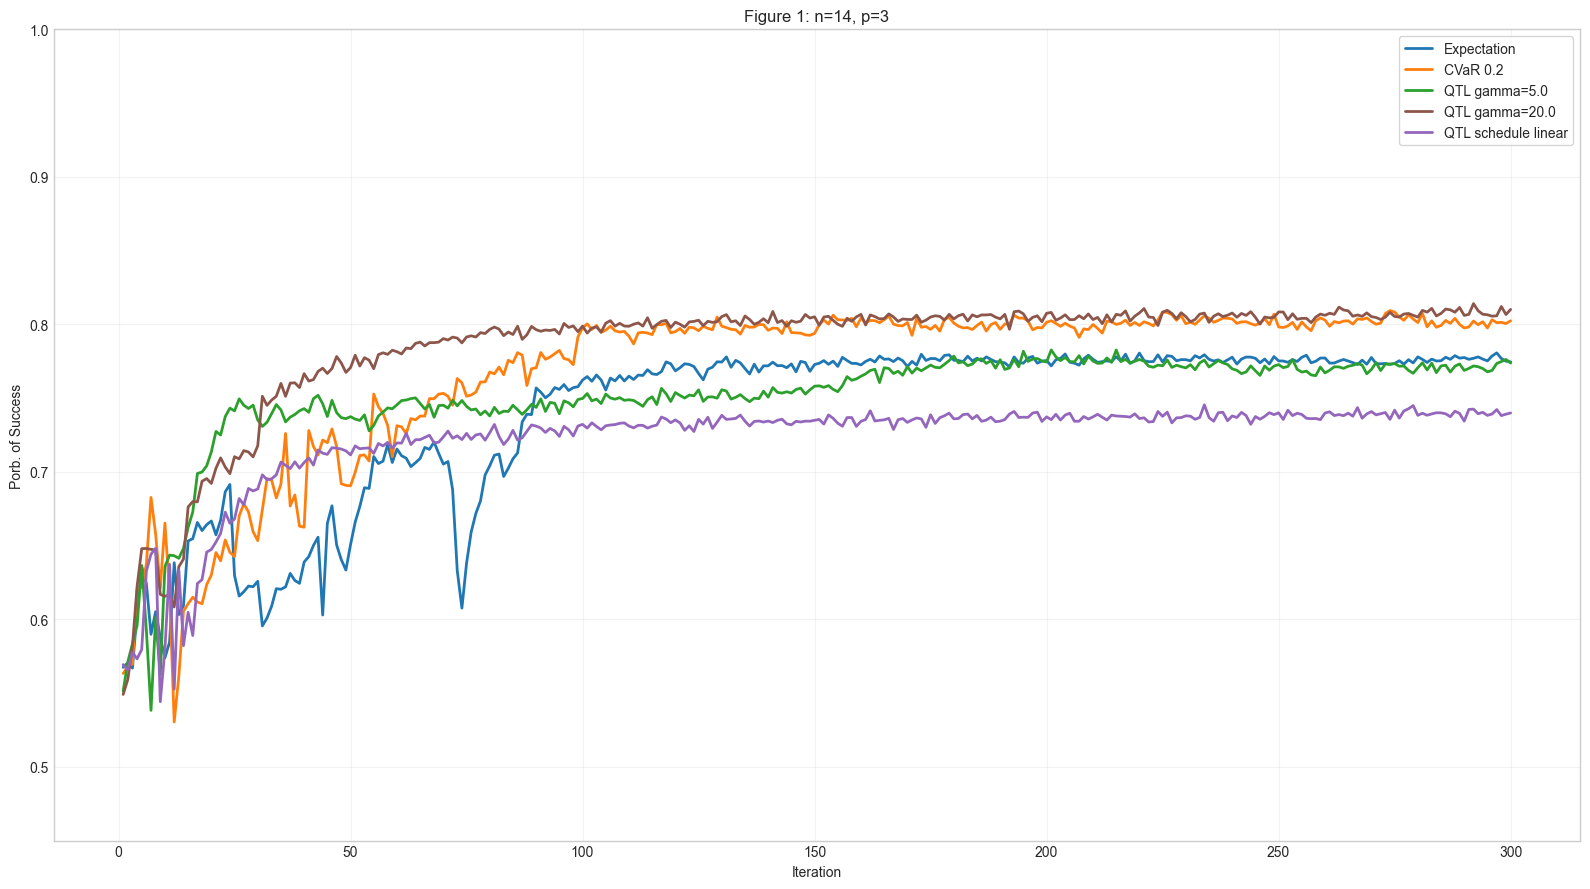

In [104]:
# fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(16, 9), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]
    
for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    for name in CURVE_OBJECTIVES:
        plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "mean_ratio",
            name,
            OBJECTIVE_COLORS[name],
        )
    ax.set_title(f"Figure 1: n={RUN_CONFIG['curve_n']}, p={p}")
    # ax.set_xticks(list(range(1, len(sub[sub["objective"] == name]) + 1)))
    ax.locator_params(axis='x', integer=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Porb. of Success")
    ax.set_ylim(0.45, 1.00)
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()

In [105]:
@dataclass(frozen=True)
class ObjectiveSpec:
    name: str
    kind: str
    alpha: float | None = None
    gamma: float | None = None
    gamma_start: float | None = None
    gamma_end: float | None = None
    schedule: str | None = None
    color: str = "C0"


MAIN_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("CVaR 0.2", "cvar", alpha=0.2, color="#ff7f0e"),
    ObjectiveSpec("QTL gamma=5.0", "qtl", gamma=5.0, color="#2ca02c"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="linear",
        color="#9467bd",
    ),
]

SCHEDULE_OBJECTIVES = [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("QTL gamma=20.0", "qtl", gamma=20.0, color="#8c564b"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="linear",
        color="#9467bd",
    ),
    ObjectiveSpec(
        "QTL schedule sigmoid",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="sigmoid",
        color="#e377c2",
    ),
    ObjectiveSpec(
        "QTL reverse linear",
        "qtl_schedule",
        gamma_start=200,
        gamma_end=0.25,
        schedule="linear",
        color="#7f7f7f",
    ),
]

FIXED_GAMMA_GRID = [0.5, 5, 20, 100, 200]
GAMMA_GRID_OBJECTIVES = [
    ObjectiveSpec(f"QTL gamma={gamma}", "qtl", gamma=gamma, color=plt.cm.viridis(i / (len(FIXED_GAMMA_GRID) - 1)))
    for i, gamma in enumerate(FIXED_GAMMA_GRID)
] + [
    ObjectiveSpec("Expectation", "expectation", color="#1f77b4"),
    ObjectiveSpec("CVaR 0.2", "cvar", alpha=0.2, color="#ff7f0e"),
    ObjectiveSpec(
        "QTL schedule linear",
        "qtl_schedule",
        gamma_start=0.25,
        gamma_end=200,
        schedule="linear",
        color="#9467bd",
    ),
]

CURVE_OBJECTIVES = ["Expectation", "CVaR 0.2", "QTL gamma=5.0", "QTL gamma=20.0", "QTL schedule linear"]
HARD_OBJECTIVES = ["Expectation", "CVaR 0.2", "QTL gamma=20.0", "QTL schedule linear"]
BUDGET_OBJECTIVES = ["Expectation", "CVaR 0.2", "QTL gamma=20.0", "QTL schedule linear"]

ALL_OBJECTIVES = {
    obj.name: obj
    for obj in MAIN_OBJECTIVES + SCHEDULE_OBJECTIVES + GAMMA_GRID_OBJECTIVES
}
OBJECTIVE_COLORS = {name: obj.color for name, obj in ALL_OBJECTIVES.items()}

FAST_CONFIG = {
    "graph_families": ["regular3"],
    # "graph_families": ["erdos_renyi"],
    "sizes": [14],
    # "sizes": [8, 10, 12],
    # "depths": [1, 2, 3],
    "depths": [3],
    "seeds": [0, 1, 2],
    "steps": 300,
    "shots": 1024,
    "gradient_probes": 4,
    "target_ratio": 0.99,
    "curve_n": 14,
    "summary_n": 14,
    "summary_p": 3,
    "budget_n": 14,
    "budget_p": 3,
    "budget_seeds": [0, 1, 2],
    "budget_shots_grid": [64, 128, 256, 512],
    "budget_total_shots": 15360,
    "gamma_grid_n": 14,
    "gamma_grid_p": 3,
    "schedule_n": 14,
    "schedule_p": 3,
}

FULL_CONFIG = {
    **FAST_CONFIG,
    # "graph_families": ["erdos_renyi"],
    "graph_families": ["regular3"],
    # "graph_families": ["regular3", "erdos_renyi"],
    "seeds": list(range(8)),
    "steps": 300,
    "shots": 1024,
    "gradient_probes": 8,
    "budget_seeds": list(range(8)),
}

RUN_CONFIG = FAST_CONFIG
print("Running config:", RUN_CONFIG)


Running config: {'graph_families': ['regular3'], 'sizes': [14], 'depths': [3], 'seeds': [0, 1, 2], 'steps': 300, 'shots': 1024, 'gradient_probes': 4, 'target_ratio': 0.99, 'curve_n': 14, 'summary_n': 14, 'summary_p': 3, 'budget_n': 14, 'budget_p': 3, 'budget_seeds': [0, 1, 2], 'budget_shots_grid': [64, 128, 256, 512], 'budget_total_shots': 15360, 'gamma_grid_n': 14, 'gamma_grid_p': 3, 'schedule_n': 14, 'schedule_p': 3}


In [106]:
curve_df, final_df, grad_df = run_benchmark(RUN_CONFIG, MAIN_OBJECTIVES)
# budget_df = run_budget_tradeoff(RUN_CONFIG, BUDGET_OBJECTIVES)


fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]

Benchmark: family=regular3, n=14, p=3, seed=0
Benchmark: family=regular3, n=14, p=3, seed=1
Benchmark: family=regular3, n=14, p=3, seed=2


In [107]:
def jump_points(x, y):
    x_new = [(x[i] + x[i + 1] + x[i + 2]) / 3 for i in range(0, int(len(x) / 3), 3)]
    y_new = [(y[i] + y[i + 1] + y[i + 2]) / 3 for i in range(0, int(len(y) / 3), 3)]
    return x_new, y_new

def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    # x, y = jump_points(agg[x_col], agg["mean"])
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )


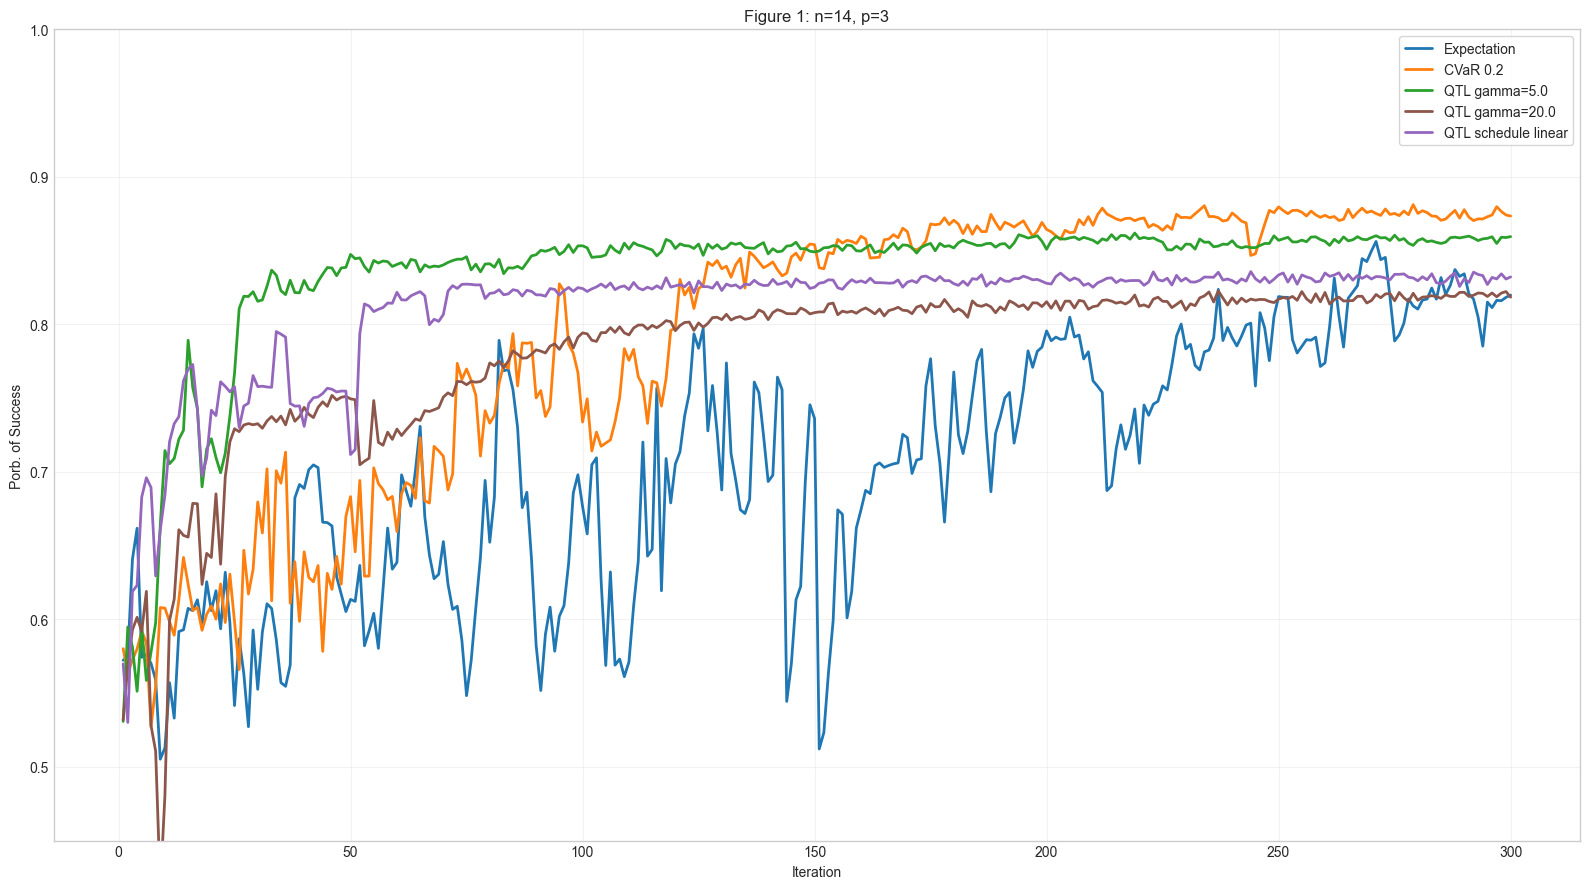

In [108]:
# fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(16, 9), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]
    
for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    for name in CURVE_OBJECTIVES:
        plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "mean_ratio",
            name,
            OBJECTIVE_COLORS[name],
        )
    ax.set_title(f"Figure 1: n={RUN_CONFIG['curve_n']}, p={p}")
    # ax.set_xticks(list(range(1, len(sub[sub["objective"] == name]) + 1)))
    ax.locator_params(axis='x', integer=True)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Porb. of Success")
    ax.set_ylim(0.45, 1.00)
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()

In [64]:
def plot_scatter(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    ax.scatter(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )

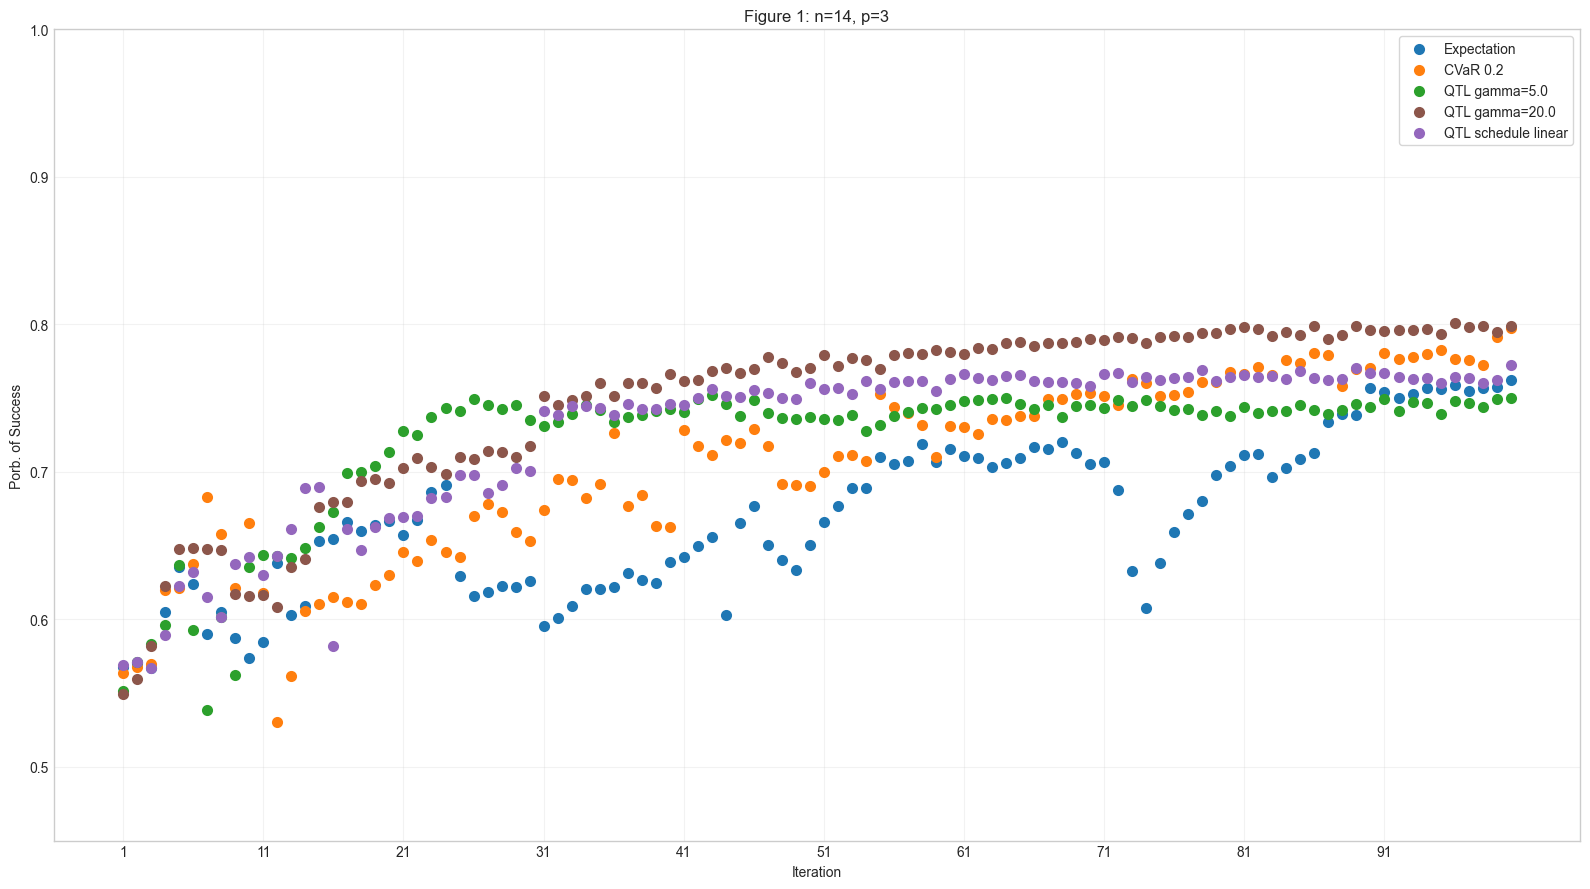

In [65]:
# fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(16, 9), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]
    
for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    for name in CURVE_OBJECTIVES:
        plot_scatter(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "mean_ratio",
            name,
            OBJECTIVE_COLORS[name],
        )
    ax.set_title(f"Figure 1: n={RUN_CONFIG['curve_n']}, p={p}")
    ax.set_xticks(list(range(1, RUN_CONFIG['steps'] + 1, 10)))
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Porb. of Success")
    ax.set_ylim(0.45, 1.00)
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()

In [51]:
curve_df, final_df, grad_df = run_benchmark(RUN_CONFIG, MAIN_OBJECTIVES)
# budget_df = run_budget_tradeoff(RUN_CONFIG, BUDGET_OBJECTIVES)

gamma_config = {
    **RUN_CONFIG,
    "sizes": [RUN_CONFIG["gamma_grid_n"]],
    "depths": [RUN_CONFIG["gamma_grid_p"]],
    "gradient_probes": 0,
}
gamma_curve_df, gamma_final_df, _ = run_benchmark(gamma_config, GAMMA_GRID_OBJECTIVES)

schedule_config = {
    **RUN_CONFIG,
    "sizes": [RUN_CONFIG["schedule_n"]],
    "depths": [RUN_CONFIG["schedule_p"]],
    "gradient_probes": 0,
}
schedule_curve_df, schedule_final_df, _ = run_benchmark(schedule_config, SCHEDULE_OBJECTIVES)

hard_final_df = annotate_instance_difficulty(final_df, quantile=0.4)
landscape_demo = find_landscape_demo()

print("curve_df shape:", curve_df.shape)
print("final_df shape:", final_df.shape)
print("grad_df shape:", grad_df.shape)
# print("budget_df shape:", budget_df.shape)
print("gamma_final_df shape:", gamma_final_df.shape)
print("schedule_final_df shape:", schedule_final_df.shape)
print(
    "landscape demo seeds:",
    landscape_demo["graph_seed"],
    landscape_demo["init_seed"],
)


Benchmark: family=erdos_renyi, n=14, p=3, seed=0
Benchmark: family=erdos_renyi, n=14, p=3, seed=1
Benchmark: family=erdos_renyi, n=14, p=3, seed=2
Shot budget sweep: shots=64, steps=80
Shot budget sweep: shots=128, steps=40
Shot budget sweep: shots=256, steps=20
Shot budget sweep: shots=512, steps=10
Benchmark: family=erdos_renyi, n=10, p=2, seed=0
Benchmark: family=erdos_renyi, n=10, p=2, seed=1
Benchmark: family=erdos_renyi, n=10, p=2, seed=2
Benchmark: family=erdos_renyi, n=12, p=1, seed=0
Benchmark: family=erdos_renyi, n=12, p=1, seed=1
Benchmark: family=erdos_renyi, n=12, p=1, seed=2


KeyError: 'QTL gamma=4.0'

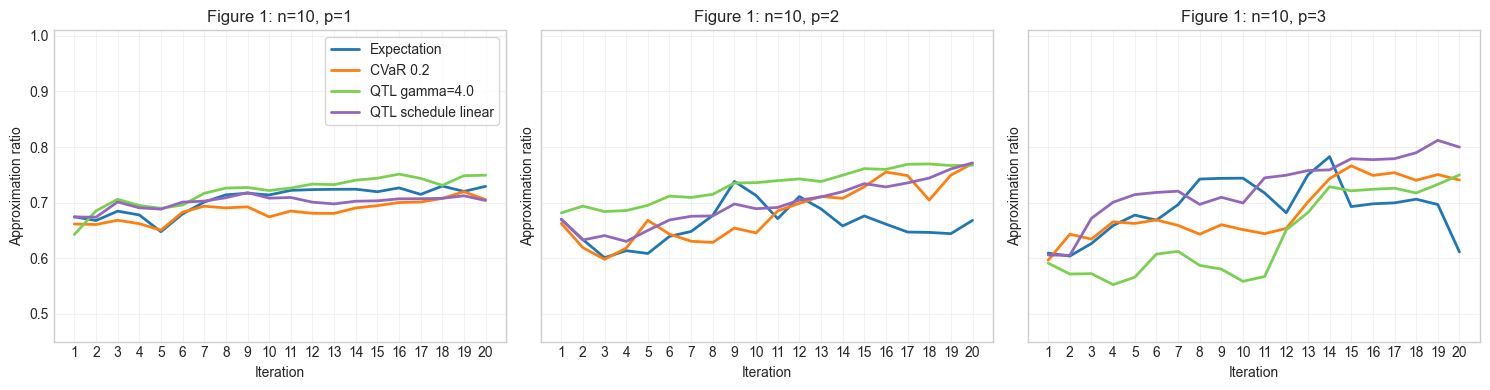

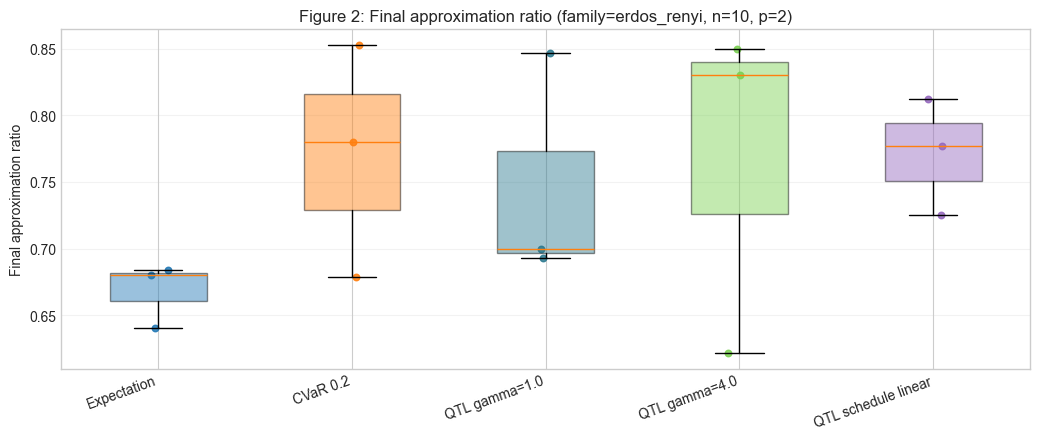

In [27]:
def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )


fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]

fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]

for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig1_df[fig1_df["p"] == p]
    for name in CURVE_OBJECTIVES:
        plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "iteration",
            "mean_ratio",
            name,
            OBJECTIVE_COLORS[name],
        )
    ax.set_title(f"Figure 1: n={RUN_CONFIG['curve_n']}, p={p}")
    ax.set_xticks(list(range(1, RUN_CONFIG['steps'] + 1)))
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Approximation ratio")
    ax.set_ylim(0.45, 1.01)
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()


fig2_df = final_df[
    (final_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (final_df["n"] == RUN_CONFIG["summary_n"])
    & (final_df["p"] == RUN_CONFIG["summary_p"])
]
order = [spec.name for spec in MAIN_OBJECTIVES]
data = [fig2_df.loc[fig2_df["objective"] == name, "final_mean_ratio"].values for name in order]

fig, ax = plt.subplots(figsize=(10.5, 4.5))
box = ax.boxplot(data, tick_labels=order, patch_artist=True, showfliers=False)
for patch, name in zip(box["boxes"], order):
    patch.set_facecolor(OBJECTIVE_COLORS[name])
    patch.set_alpha(0.45)
rng = np.random.default_rng(123)
for i, name in enumerate(order, start=1):
    values = fig2_df.loc[fig2_df["objective"] == name, "final_mean_ratio"].values
    if len(values):
        jitter = rng.normal(loc=i, scale=0.04, size=len(values))
        ax.scatter(jitter, values, s=22, color=OBJECTIVE_COLORS[name], alpha=0.85)

ax.set_title(
    f"Figure 2: Final approximation ratio (family={RUN_CONFIG['graph_families'][0]}, "
    f"n={RUN_CONFIG['summary_n']}, p={RUN_CONFIG['summary_p']})"
)
ax.set_ylabel("Final approximation ratio")
ax.set_xticklabels(order, rotation=20, ha="right")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, len(RUN_CONFIG["depths"]), figsize=(5 * len(RUN_CONFIG["depths"]), 4), sharey=True)
if len(RUN_CONFIG["depths"]) == 1:
    axes = [axes]

fig3_df = grad_df[
    (grad_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (grad_df["objective"].isin(CURVE_OBJECTIVES))
]

for ax, p in zip(axes, RUN_CONFIG["depths"]):
    sub = fig3_df[fig3_df["p"] == p]
    for name in CURVE_OBJECTIVES:
        plot_mean_with_band(
            ax,
            sub[sub["objective"] == name],
            "n",
            "grad_norm_mean",
            name,
            OBJECTIVE_COLORS[name],
        )
    ax.set_title(f"Figure 3: Initial gradient proxy, p={p}")
    ax.set_xlabel("Problem size n")
    ax.set_ylabel("Gradient norm proxy")
    ax.grid(alpha=0.25)

axes[0].legend(frameon=True)
plt.tight_layout()
plt.show()


fig4_df = (
    budget_df.groupby(["shots_per_eval", "objective"])["final_mean_ratio"]
    .agg(["mean", "std"])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for name in BUDGET_OBJECTIVES:
    sub = fig4_df[fig4_df["objective"] == name].sort_values("shots_per_eval")
    ax.plot(
        sub["shots_per_eval"],
        sub["mean"],
        marker="o",
        linewidth=2,
        label=name,
        color=OBJECTIVE_COLORS[name],
    )
    std = sub["std"].fillna(0.0)
    ax.fill_between(
        sub["shots_per_eval"],
        sub["mean"] - std,
        sub["mean"] + std,
        color=OBJECTIVE_COLORS[name],
        alpha=0.15,
    )

ax.set_title(
    f"Figure 4: Shot-budget trade-off (family={RUN_CONFIG['graph_families'][0]}, "
    f"n={RUN_CONFIG['budget_n']}, p={RUN_CONFIG['budget_p']}, total shots fixed)"
)
ax.set_xlabel("Shots per objective evaluation")
ax.set_ylabel("Final approximation ratio")
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


summary_table = (
    final_df.groupby("objective")
    .agg(
        final_ratio_mean=("final_mean_ratio", "mean"),
        final_ratio_std=("final_mean_ratio", "std"),
        best_ratio_mean=("final_best_ratio", "mean"),
        success_rate=("success_target", "mean"),
        steps_to_target=("steps_to_target", "mean"),
        loss_volatility=("loss_volatility", "mean"),
    )
    .sort_values("final_ratio_mean", ascending=False)
)

init_table = (
    grad_df.groupby("objective")
    .agg(
        init_grad_norm=("grad_norm_mean", "mean"),
        init_grad_var=("grad_norm_var", "mean"),
        init_objective_var=("objective_var", "mean"),
    )
    .sort_values("init_grad_norm", ascending=False)
)

print("Final performance summary")
display(summary_table.round(4))

print("Initialization / estimation summary")
display(init_table.round(4))


In [8]:
# Code to generate the graph
def make_graph(n, family, seed):
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        p = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, p, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, p, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph

Hamiltonian for 10-node MaxCut:
 0.5 * (Z(0) @ Z(3)) + 0.5 * (Z(0) @ Z(4)) + 0.5 * (Z(0) @ Z(5)) + 0.5 * (Z(1) @ Z(5)) + 0.5 * (Z(1) @ Z(6)) + 0.5 * (Z(1) @ Z(8)) + 0.5 * (Z(1) @ Z(9)) + 0.5 * (Z(2) @ Z(3)) + 0.5 * (Z(2) @ Z(4)) + 0.5 * (Z(2) @ Z(5)) + 0.5 * (Z(2) @ Z(6)) + 0.5 * (Z(2) @ Z(9)) + 0.5 * (Z(3) @ Z(4)) + 0.5 * (Z(4) @ Z(6)) + 0.5 * (Z(4) @ Z(7)) + 0.5 * (Z(4) @ Z(9)) + 0.5 * (Z(5) @ Z(6)) + 0.5 * (Z(5) @ Z(7)) + 0.5 * (Z(5) @ Z(8)) + 0.5 * (Z(6) @ Z(9)) + -0.5 * I(0) + -0.5 * I(1) + -0.5 * I(2) + -0.5 * I(3) + -0.5 * I(4) + -0.5 * I(5) + -0.5 * I(6) + -0.5 * I(7) + -0.5 * I(8) + -0.5 * I(9) + -0.5 * I(10) + -0.5 * I(11) + -0.5 * I(12) + -0.5 * I(13) + -0.5 * I(14) + -0.5 * I(15) + -0.5 * I(16) + -0.5 * I(17) + -0.5 * I(18) + -0.5 * I(19)


In [12]:
dev = qml.device('default.qubit', wires=n)

# QAOA Ansatz
def qaoa_layer(gamma, beta, edges):
    for i, j in edges:
        qml.IsingZZ(2 * gamma, wires=[i, j])
    for i in range(n):
        qml.RX(2 * beta, wires=i)

@qml.qnode(dev)
def qaoa_circuit(params, p=1):
    # Start in superposition
    for i in range(n):
        qml.Hadamard(wires=i)
    # p layers of QAOA
    alphas = params[:p]
    betas = params[p:]
    for i in range(p):
        qaoa_layer(alphas[i], betas[i], edges)
    return qml.probs(wires=range(n))

# Hardware Efficient Ansatz (HEA)
@qml.qnode(dev)
def hea_circuit(params, layers=2):
    # params shape: (layers, n, 2) for RY and RZ
    idx = 0
    for L in range(layers):
        for i in range(n):
            qml.RY(params[idx], wires=i); idx += 1
            qml.RZ(params[idx], wires=i); idx += 1
        # Entanglement (ring of CNOTs)
        for i in range(n):
            qml.CNOT(wires=[i, (i + 1) % n])
    # Final rotation layer
    for i in range(n):
        qml.RY(params[idx], wires=i); idx += 1
    return qml.probs(wires=range(n))

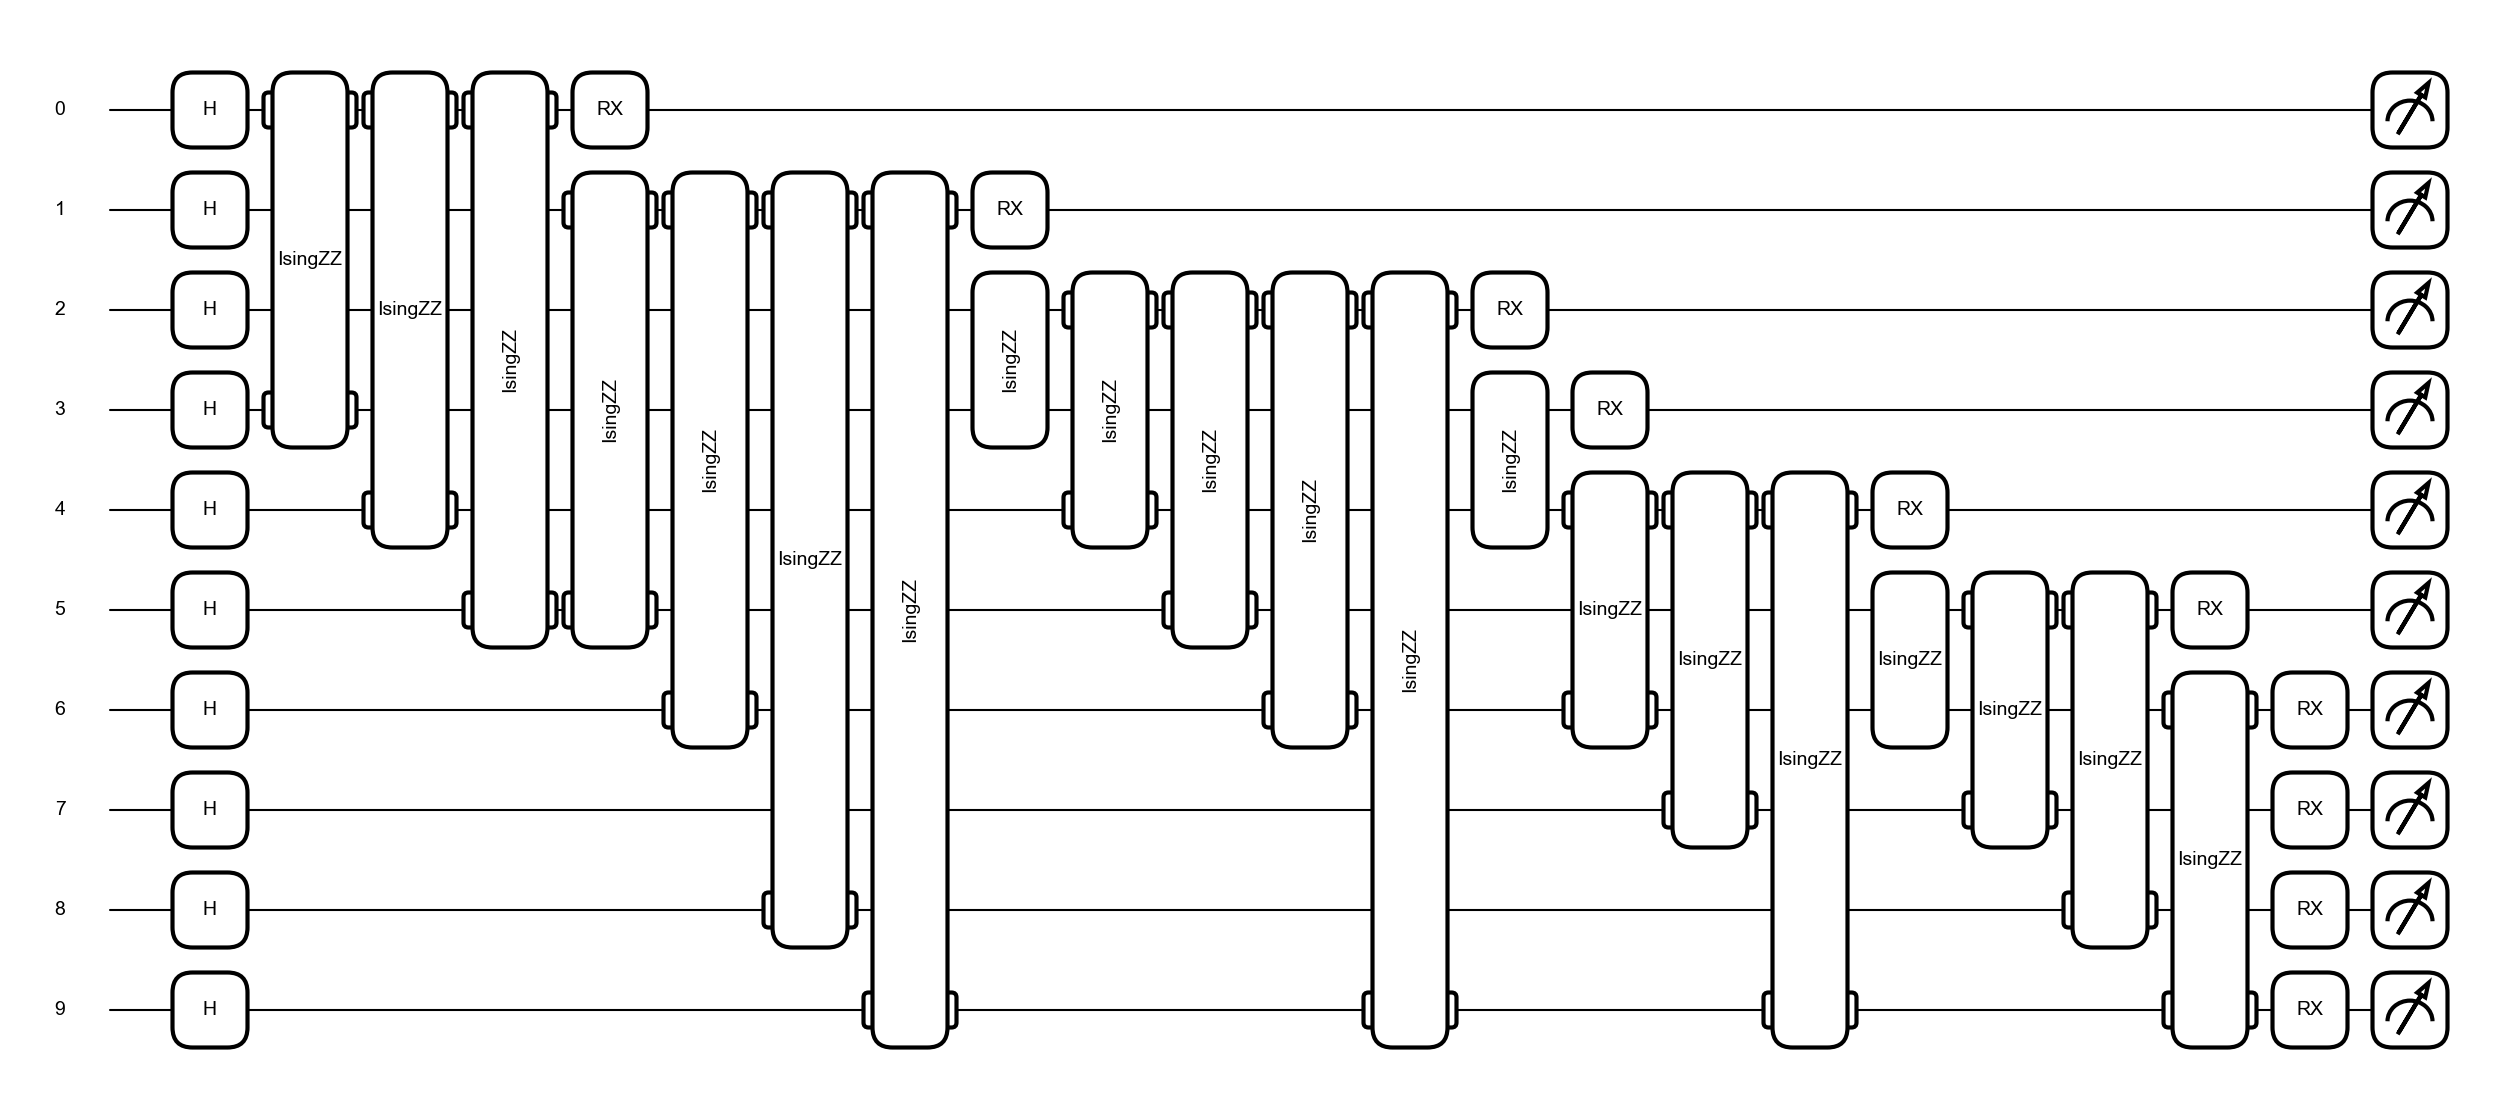

In [13]:
p = 1
sample_params = np.array([0.5, 1.0])
fig, ax = qml.draw_mpl(qaoa_circuit)(sample_params, p=p)
plt.show()

In [14]:
def get_energies(n, edges):
    # Precompute eigenvalues of the MaxCut Hamiltonian for all basis states
    energies = []
    for i in range(2**n):
        bitstring = format(i, f'0{n}b')
        spins = [1 if b == '0' else -1 for b in bitstring]
        energy = 0
        for u, v in edges:
            energy += 0.5 * (spins[u] * spins[v] - 1)
        energies.append(energy)
    return np.array(energies)

energies = get_energies(n, edges)

def standard_loss(probs):
    return np.dot(probs, energies)

def tilted_loss(probs, gamma_val):
    # Avoid gamma = 0 to prevent division by zero; use standard limit
    if abs(gamma_val) < 1e-9:
        return standard_loss(probs)
    # tr(exp(-gamma*H) * rho) = sum(p_i * exp(-gamma * E_i))
    expectation_exp = np.dot(probs, np.exp(-gamma_val * energies))
    return - (1.0 / gamma_val) * np.log(expectation_exp)

In [15]:
def basis_states(n):
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)

def cut_values_from_samples(samples, edges):
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts

def exact_cut_data(n, edges):
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())


Here we define various types of the loss functions, including standard loss function, CVaR loss function, and the tilted loss function.

In [16]:
def cvar_loss(losses, alpha):
    k = max(1, int(math.ceil(alpha * len(losses))))
    return float(np.mean(np.partition(losses, k - 1)[:k]))


def qtl_loss(losses, gamma):
    losses = np.asarray(losses, dtype=float)
    if gamma is None or abs(gamma) < 1e-12:
        return float(np.mean(losses))
    loss_min = float(losses.min())
    shifted = losses - loss_min
    return float(loss_min - np.log(np.mean(np.exp(-gamma * shifted))) / gamma)


def sampled_loss(cuts, c_max, spec, step, total_steps):
    losses = c_max - np.asarray(cuts, dtype=float)
    if spec.kind == "expectation":
        return float(np.mean(losses)), np.nan
    if spec.kind == "cvar":
        return cvar_loss(losses, spec.alpha), np.nan
    gamma = scheduled_gamma(spec, step, total_steps)
    return qtl_loss(losses, gamma), gamma

    
def make_evaluator(n, edges, c_max, shots, spec, total_steps, device_seed):
    sampler = make_qaoa_sampler(n, edges, shots, device_seed=device_seed)

    def evaluate(params, step):
        params = np.asarray(params, dtype=float)
        wrapped = np.mod(params, 2 * np.pi)
        samples = np.asarray(sampler(wrapped), dtype=int)
        cuts = cut_values_from_samples(samples, edges)
        loss, gamma = sampled_loss(cuts, c_max, spec, step, total_steps)
        return loss, {
            "mean_cut": float(np.mean(cuts)),
            "best_cut": int(np.max(cuts)),
            "mean_ratio": float(np.mean(cuts) / c_max),
            "best_ratio": float(np.max(cuts) / c_max),
            "c_max": float(c_max),
            "gamma": gamma,
        }

    return evaluate



In [19]:
fixed_spec = ALL_OBJECTIVES["QTL gamma=4.0"]
sched_spec = ALL_OBJECTIVES["QTL schedule linear"]
reverse_spec = ALL_OBJECTIVES["QTL reverse linear"]

gamma_config = {
    **RUN_CONFIG,
    "sizes": [RUN_CONFIG["gamma_grid_n"]],
    "depths": [RUN_CONFIG["gamma_grid_p"]],
    "gradient_probes": 0,
}

schedule_config = {
    **RUN_CONFIG,
    "sizes": [RUN_CONFIG["schedule_n"]],
    "depths": [RUN_CONFIG["schedule_p"]],
    "gradient_probes": 0,
}


_, cuts, c_max = exact_cut_data(n, edges)
init_rng = np.random.default_rng(10_000 * n + 100 * p + fixed_spec["seeds"])
init_params = init_rng.uniform(0.0, np.pi, size=2 * p)


best = None
best_gap = -np.inf

evaluator = make_evaluator(
    n,
    edges,
    c_max,
    gamma_config["shots"],
    fixed_spec,
    gamma_config["steps"],
    device_seed=2024 + 100 * seed + 10 * p + n,
)

def estimate_initial_statistics(evaluate, init_params, probes, rng, epsilon=0.15):
    if probes <= 0:
        return {
            "grad_norm_mean": np.nan,
            "grad_norm_var": np.nan,
            "objective_var": np.nan,
        }
    norms = []
    values = []
    for _ in range(probes):
        delta = rng.choice([-1.0, 1.0], size=len(init_params))
        loss_plus, _ = evaluate(init_params + epsilon * delta, step=0)
        loss_minus, _ = evaluate(init_params - epsilon * delta, step=0)
        grad = (loss_plus - loss_minus) / (2.0 * epsilon) * delta
        norms.append(np.linalg.norm(grad))
        values.extend([loss_plus, loss_minus])
    return {
        "grad_norm_mean": float(np.mean(norms)),
        "grad_norm_var": float(np.var(norms)),
        "objective_var": float(np.var(values)),
    }

def spsa_optimize(evaluate, init_params, steps, shots, rng, a=0.18, c=0.12, A=8.0):
    params = np.asarray(init_params, dtype=float).copy()
    best_cut_so_far = -np.inf
    history = []

    for step in range(steps):
        delta = rng.choice([-1.0, 1.0], size=len(params))
        ck = c / ((step + 1) ** 0.101)
        ak = a / ((step + 1 + A) ** 0.602)

        loss_plus, plus_metrics = evaluate(params + ck * delta, step)
        loss_minus, minus_metrics = evaluate(params - ck * delta, step)
        grad = (loss_plus - loss_minus) / (2.0 * ck) * delta

        params = np.mod(params - ak * grad, 2 * np.pi)
        loss_cur, cur_metrics = evaluate(params, step)

        best_cut_so_far = max(
            best_cut_so_far,
            plus_metrics["best_cut"],
            minus_metrics["best_cut"],
            cur_metrics["best_cut"],
        )

        history.append(
            {
                "iteration": step + 1,
                "loss": float(loss_cur),
                "mean_ratio": float(cur_metrics["mean_ratio"]),
                "best_ratio_step": float(cur_metrics["best_ratio"]),
                "best_ratio_so_far": float(best_cut_so_far / cur_metrics["c_max"]),
                "best_cut_so_far": int(best_cut_so_far),
                "shots_used": int((step + 1) * 3 * shots),
                "gamma": cur_metrics["gamma"],
            }
        )

    return params, pd.DataFrame(history)
    
init_stats = estimate_initial_statistics(
    evaluator,
    init_params,
    probes=gamma_config["gradient_probes"],
    rng=grad_rng,
)
_, history = spsa_optimize(
    evaluator,
    init_params,
    steps=gamma_config["steps"],
    shots=gamma_config["shots"],
    rng=opt_rng,
)

TypeError: 'ObjectiveSpec' object is not subscriptable

Optimizing Standard QAOA...
Optimizing Tilted QAOA...


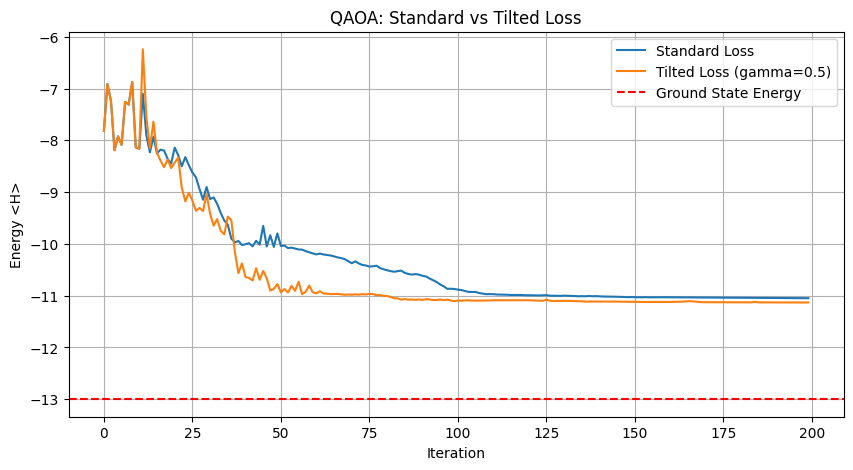

In [36]:
p = 5
init_params = np.random.uniform(0, np.pi, 2 * p, requires_grad=True)
gamma_fixed = 0.5

history_std = []
history_tilted = []

def cost_std(params):
    probs = qaoa_circuit(params, p=p)
    loss = standard_loss(probs)
    history_std.append(loss)
    return loss

def cost_tilted(params):
    probs = qaoa_circuit(params, p=p)
    loss = tilted_loss(probs, gamma_fixed)
    # For comparison, we store the actual energy
    history_tilted.append(standard_loss(probs))
    return loss

print('Optimizing Standard QAOA...')
res_std = minimize(cost_std, init_params, method='COBYLA', options={'maxiter': 200})

print('Optimizing Tilted QAOA...')
res_tilted = minimize(cost_tilted, init_params, method='COBYLA', options={'maxiter': 200})

plt.figure(figsize=(10, 5))
plt.plot(history_std, label='Standard Loss')
plt.plot(history_tilted, label=f'Tilted Loss (gamma={gamma_fixed})')
plt.axhline(y=min(energies), color='r', linestyle='--', label='Ground State Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy <H>')
plt.title('QAOA: Standard vs Tilted Loss')
plt.legend()
plt.grid(True)
plt.show()

## Task 2: HEA with Tilted Loss

Optimizing HEA with Standard Loss...


e:\李修凡的资料\博三（下）\QTR\code\qi-QTR\venv\Lib\site-packages\scipy\_lib\pyprima\common\preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 172
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


Optimizing HEA with Tilted Loss...


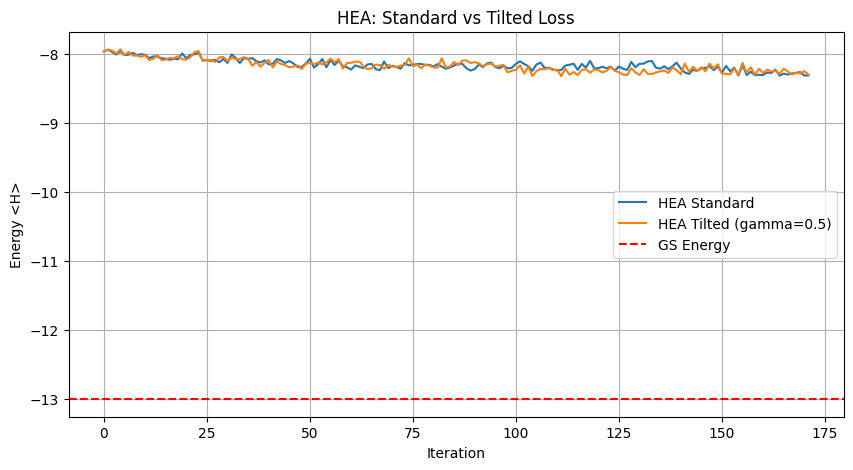

In [25]:
hea_layers = 8
num_params = hea_layers * n * 2 + n
init_params_hea = np.random.uniform(0, 2 * np.pi, num_params, requires_grad=True)

history_hea_std = []
history_hea_tilted = []

def cost_hea_std(params):
    probs = hea_circuit(params, layers=hea_layers)
    loss = standard_loss(probs)
    history_hea_std.append(loss)
    return loss

def cost_hea_tilted(params):
    probs = hea_circuit(params, layers=hea_layers)
    loss = tilted_loss(probs, gamma_fixed)
    history_hea_tilted.append(standard_loss(probs))
    return loss

print('Optimizing HEA with Standard Loss...')
minimize(cost_hea_std, init_params_hea, method='COBYLA', options={'maxiter': 100})

print('Optimizing HEA with Tilted Loss...')
minimize(cost_hea_tilted, init_params_hea, method='COBYLA', options={'maxiter': 100})

plt.figure(figsize=(10, 5))
plt.plot(history_hea_std, label='HEA Standard')
plt.plot(history_hea_tilted, label=f'HEA Tilted (gamma={gamma_fixed})')
plt.axhline(y=min(energies), color='r', linestyle='--', label='GS Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy <H>')
plt.title('HEA: Standard vs Tilted Loss')
plt.legend()
plt.grid(True)
plt.show()

## Task 3: Effect of Different Fixed Gamma Values

We examine and compare the algorithm performance using different fixed values of $\gamma$: 0.1, 5, 10, 20, 100.

Optimizing Tilted QAOA with gamma=0.1...
Optimizing Tilted QAOA with gamma=20...
Optimizing Tilted QAOA with gamma=200...


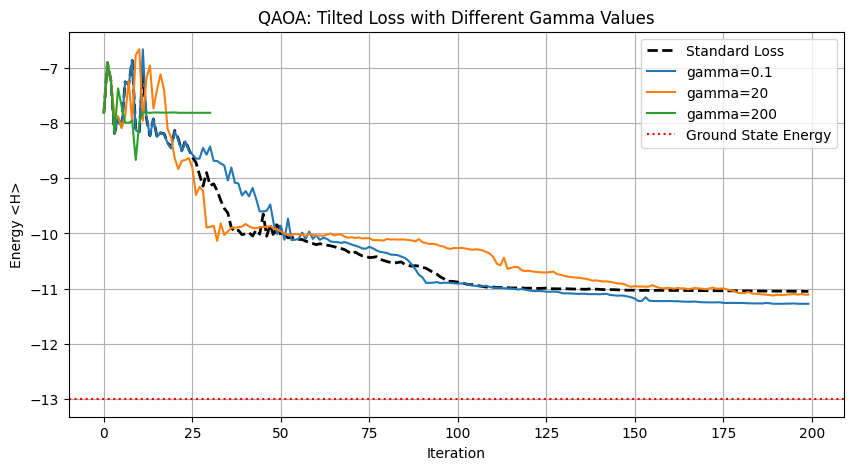

In [37]:
gamma_values = [0.1, 20, 200]
results_gamma = {}

for g in gamma_values:
    print(f'Optimizing Tilted QAOA with gamma={g}...')
    hist = []
    def cost_tilted_g(params):
        probs = qaoa_circuit(params, p=p)
        loss = tilted_loss(probs, g)
        hist.append(standard_loss(probs))
        return loss
    minimize(cost_tilted_g, init_params, method='COBYLA', options={'maxiter': 200})
    results_gamma[g] = hist

plt.figure(figsize=(10, 5))
plt.plot(history_std, label='Standard Loss', linestyle='--', color='black', linewidth=2)
for g in gamma_values:
    plt.plot(results_gamma[g], label=f'gamma={g}')
plt.axhline(y=min(energies), color='r', linestyle=':', label='Ground State Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy <H>')
plt.title('QAOA: Tilted Loss with Different Gamma Values')
plt.legend()
plt.grid(True)
plt.show()


## Task 4: Evaluating Gamma Schedules

We explore how changing $\gamma$ during optimization affects performance.
The schedules tested are:
1. **Linear**: $\gamma(t) = \gamma_0 + (\gamma_f - \gamma_0) \frac{t}{T}$
2. **Sigmoid**: $\gamma(t) = \gamma_0 + \frac{\gamma_f - \gamma_0}{1 + e^{-10 (\frac{t}{T} - 0.5)}}$
3. **Exponential**: $\gamma(t) = \gamma_0 \left( \frac{\gamma_f}{\gamma_0} \right)^{\frac{t}{T}}$
4. **Logarithmic**: $\gamma(t) = \gamma_0 + (\gamma_f - \gamma_0) \frac{\ln(1 + t)}{\ln(1 + T)}$

In [ ]:
def _sigmoid_frac(frac):
    base = 1.0 / (1.0 + np.exp(-12.0 * (frac - 0.5)))
    low = 1.0 / (1.0 + np.exp(6.0))
    high = 1.0 / (1.0 + np.exp(-6.0))
    return float((base - low) / (high - low))

    
def scheduled_gamma(spec, step, total_steps):
    if spec.kind != "qtl_schedule":
        return spec.gamma
    if total_steps <= 1:
        return float(spec.gamma_end)
    frac = step / (total_steps - 1)
    if spec.schedule == "linear":
        schedule_frac = frac
    elif spec.schedule == "sigmoid":
        schedule_frac = _sigmoid_frac(frac)
    elif spec.schedule == "piecewise":
        if frac < 0.5:
            schedule_frac = 0.2 * frac / 0.5
        else:
            schedule_frac = 0.2 + 0.8 * (frac - 0.5) / 0.5
    else:
        raise ValueError(f"Unknown schedule: {spec.schedule}")
    return float(spec.gamma_start + schedule_frac * (spec.gamma_end - spec.gamma_start))



Testing linear schedule...
Testing sigmoid schedule...
Testing exponential schedule...
Testing logarithmic schedule...


/usr/local/lib/python3.12/dist-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 22
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


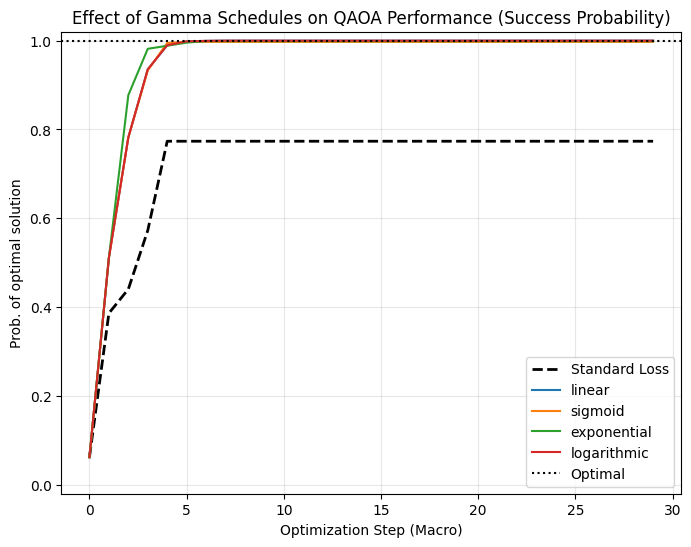

In [ ]:
T = 30 # Total macro iterations
gamma_0, gamma_f = 0.01, 50

E_gs = float(np.min(energies))
gs_mask = np.isclose(energies, E_gs)

def success_prob_from_probs(probs):
    # probs may be a pennylane array; cast to plain numpy for masking + sum
    probs_np = np.array(probs, dtype=float)
    return float(np.sum(probs_np[gs_mask]))

def get_gamma_schedule(name, t, T):
    if name == 'linear':
        return gamma_0 + (gamma_f - gamma_0) * (t / T)
    elif name == 'sigmoid':
        return gamma_0 + (gamma_f - gamma_0) / (1 + np.exp(-10 * (t/T - 0.5)))
    elif name == 'exponential':
        return gamma_0 * (gamma_f / gamma_0)**(t / T)
    elif name == 'logarithmic':
        return gamma_0 + (gamma_f - gamma_0) * np.log(1 + t) / np.log(1 + T)
    return gamma_0

schedules = ['linear', 'sigmoid', 'exponential', 'logarithmic']
results_schedules = {}

p = 10
initial_params = np.random.uniform(0, np.pi, 2 * p, requires_grad=True)

for sched in schedules:
    print(f'Testing {sched} schedule...')
    hist = []
    params = initial_params

    # Custom optimization loop with dynamic gamma
    for t in range(T):
        current_gamma = get_gamma_schedule(sched, t, T)

        # record success probability (prob of optimal/ground-state solution)
        probs = qaoa_circuit(params, p=p)
        hist.append(success_prob_from_probs(probs))

        def cost_tilted_g(params):
            probs = qaoa_circuit(params, p=p)
            return tilted_loss(probs, current_gamma)

        res = minimize(cost_tilted_g, params, method='Nelder-Mead', options={'maxiter': 10})
        params = res.x

    results_schedules[sched] = hist

history_std = []
params = initial_params

for t in range(T):
    probs = qaoa_circuit(params, p=p)
    history_std.append(success_prob_from_probs(probs))

    def cost_std(params):
        probs = qaoa_circuit(params, p=p)
        return standard_loss(probs)

    res = minimize(cost_std, params, method='COBYLA', options={'maxiter': 10})
    params = res.x

plt.figure(figsize=(8, 6))
plt.plot(history_std, label='Standard Loss', linestyle='--', color='black', linewidth=2)
for name, data in results_schedules.items():
    plt.plot(data, label=name)

plt.axhline(y=1.0, color='black', linestyle=':', label='Optimal')
plt.xlabel('Optimization Step (Macro)')
plt.ylabel('Prob. of optimal solution')
plt.title('Effect of Gamma Schedules on QAOA Performance (Success Probability)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.02, 1.02)
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-510/1808751342.py:9: SyntaxWarning: invalid escape sequence '\g'
  plt.title('QAOA Performance with ascending $\gamma(t)$')


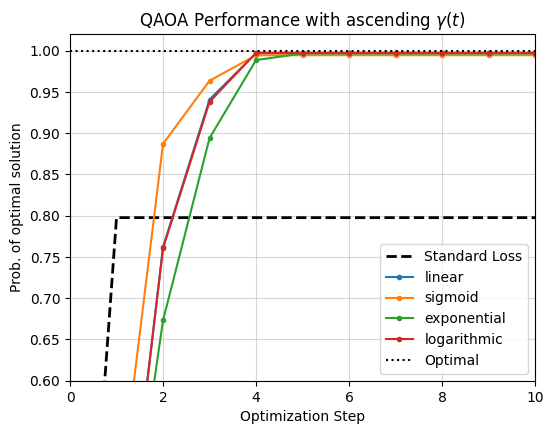

In [ ]:
plt.figure(figsize=(6, 4.5))
plt.plot(history_std, label='Standard Loss', linestyle='--', color='black', linewidth=2)
for name, data in results_schedules.items():
    plt.plot(data, marker='.', label=name)

plt.axhline(y=1.0, color='black', linestyle=':', label='Optimal')
plt.xlabel('Optimization Step')
plt.ylabel('Prob. of optimal solution')
plt.title('QAOA Performance with ascending $\gamma(t)$')
plt.legend()
plt.grid(alpha=0.5)
plt.ylim(0.6, 1.02)
plt.xlim(0, 10)
plt.show()

In [ ]:
gamma_sub = gamma_final_df[
    (gamma_final_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (gamma_final_df["n"] == RUN_CONFIG["gamma_grid_n"])
    & (gamma_final_df["p"] == RUN_CONFIG["gamma_grid_p"])
]
gamma_fixed = gamma_sub[gamma_sub["objective"].str.startswith("QTL gamma=")].copy()
gamma_fixed["gamma_value"] = gamma_fixed["objective"].str.replace("QTL gamma=", "", regex=False).astype(float)
gamma_summary = gamma_fixed.groupby("gamma_value").agg(
    final_ratio_mean=("final_mean_ratio", "mean"),
    final_ratio_std=("final_mean_ratio", "std"),
).reset_index()

schedule_level = gamma_sub[gamma_sub["objective"] == "QTL schedule linear"]["final_mean_ratio"]
expectation_level = gamma_sub[gamma_sub["objective"] == "Expectation"]["final_mean_ratio"]
cvar_level = gamma_sub[gamma_sub["objective"] == "CVaR 0.2"]["final_mean_ratio"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].errorbar(
    gamma_summary["gamma_value"],
    gamma_summary["final_ratio_mean"],
    yerr=gamma_summary["final_ratio_std"].fillna(0.0),
    marker="o",
    linewidth=2,
    color="#2ca02c",
    capsize=4,
    label="Fixed gamma grid",
)
axes[0].axhline(schedule_level.mean(), color=OBJECTIVE_COLORS["QTL schedule linear"], linestyle="--", linewidth=2, label="Schedule linear")
axes[0].axhline(expectation_level.mean(), color=OBJECTIVE_COLORS["Expectation"], linestyle=":", linewidth=2, label="Expectation")
axes[0].axhline(cvar_level.mean(), color=OBJECTIVE_COLORS["CVaR 0.2"], linestyle="-.", linewidth=2, label="CVaR 0.2")
axes[0].set_xscale("log")
axes[0].set_xlabel("Fixed gamma")
axes[0].set_ylabel("Final approximation ratio")
axes[0].set_title(
    f"Figure 5a: Fixed-gamma grid (n={RUN_CONFIG['gamma_grid_n']}, p={RUN_CONFIG['gamma_grid_p']})"
)
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=True)

axes[1].plot(
    gamma_summary["gamma_value"],
    gamma_summary["final_ratio_std"].fillna(0.0),
    marker="o",
    linewidth=2,
    color="#8c564b",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Fixed gamma")
axes[1].set_ylabel("Cross-seed std of final ratio")
axes[1].set_title("Figure 5b: Tuning sensitivity across seeds")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sched_curve_sub = schedule_curve_df[
    (schedule_curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (schedule_curve_df["n"] == RUN_CONFIG["schedule_n"])
    & (schedule_curve_df["p"] == RUN_CONFIG["schedule_p"])
]
for name in [spec.name for spec in SCHEDULE_OBJECTIVES]:
    plot_mean_with_band(
        axes[0],
        sched_curve_sub[sched_curve_sub["objective"] == name],
        "iteration",
        "mean_ratio",
        name,
        OBJECTIVE_COLORS[name],
    )
axes[0].set_title(
    f"Figure 6a: Schedule ablation (n={RUN_CONFIG['schedule_n']}, p={RUN_CONFIG['schedule_p']})"
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Approximation ratio")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=True)

sched_final_summary = (
    schedule_final_df.groupby("objective")
    .agg(
        final_ratio_mean=("final_mean_ratio", "mean"),
        final_ratio_std=("final_mean_ratio", "std"),
        volatility_mean=("loss_volatility", "mean"),
    )
    .reindex([spec.name for spec in SCHEDULE_OBJECTIVES])
)
x = np.arange(len(sched_final_summary))
axes[1].bar(
    x,
    sched_final_summary["final_ratio_mean"],
    yerr=sched_final_summary["final_ratio_std"].fillna(0.0),
    color=[OBJECTIVE_COLORS[name] for name in sched_final_summary.index],
    alpha=0.65,
    capsize=4,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(sched_final_summary.index, rotation=20, ha="right")
axes[1].set_ylabel("Final approximation ratio")
axes[1].set_title("Figure 6b: Low-to-high beats reverse scheduling")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


hard_sub = hard_final_df[hard_final_df["objective"].isin(HARD_OBJECTIVES)].copy()
hard_summary = (
    hard_sub.groupby(["difficulty", "objective"])
    .agg(
        final_ratio_mean=("final_mean_ratio", "mean"),
        final_ratio_std=("final_mean_ratio", "std"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, difficulty in zip(axes, ["easy-for-expectation", "hard-for-expectation"]):
    sub = hard_summary[hard_summary["difficulty"] == difficulty].set_index("objective").reindex(HARD_OBJECTIVES).reset_index()
    x = np.arange(len(sub))
    ax.bar(
        x,
        sub["final_ratio_mean"],
        yerr=sub["final_ratio_std"].fillna(0.0),
        color=[OBJECTIVE_COLORS[name] for name in sub["objective"]],
        alpha=0.7,
        capsize=4,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(sub["objective"], rotation=20, ha="right")
    ax.set_title(f"Figure 7: {difficulty}")
    ax.set_ylabel("Final approximation ratio")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


hard_gain_table = (
    hard_sub[hard_sub["difficulty"] == "hard-for-expectation"]
    .groupby("objective")
    .agg(
        final_ratio_mean=("final_mean_ratio", "mean"),
        success_rate=("success_target", "mean"),
        volatility=("loss_volatility", "mean"),
    )
    .reindex(HARD_OBJECTIVES)
)
print("Hard-instance summary (hardness defined by bottom 40% expectation seeds within each n,p group)")
display(hard_gain_table.round(4))


In [ ]:
demo_graph = landscape_demo["graph"]
demo_edges = landscape_demo["edges"]
demo_init = landscape_demo["init_params"]
demo_fixed_trace = landscape_demo["fixed_trace"]
demo_sched_trace = landscape_demo["sched_trace"]
demo_reverse_trace = landscape_demo["reverse_trace"]

fixed_spec = ALL_OBJECTIVES["QTL gamma=4.0"]
small_spec = ObjectiveSpec("QTL gamma=0.25", "qtl", gamma=0.25, color="#2ca02c")
sched_spec = ALL_OBJECTIVES["QTL schedule linear"]

small_obj, _, _ = make_exact_objective(6, demo_edges, small_spec, total_steps=24)
fixed_obj, _, _ = make_exact_objective(6, demo_edges, fixed_spec, total_steps=24)
sched_obj, _, _ = make_exact_objective(6, demo_edges, sched_spec, total_steps=24)

gamma_axis = np.linspace(0, 2 * np.pi, 60)
beta_axis = np.linspace(0, 2 * np.pi, 60)
landscape_small = build_landscape(small_obj, gamma_axis, beta_axis, step=0)
landscape_large = build_landscape(fixed_obj, gamma_axis, beta_axis, step=0)
landscape_final = build_landscape(sched_obj, gamma_axis, beta_axis, step=23)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharex=True, sharey=True, constrained_layout=True)
meshes = [
    (axes[0], landscape_small, "Figure 8a: exact QTL landscape, gamma=0.25"),
    (axes[1], landscape_large, "Figure 8b: exact QTL landscape, gamma=4.0"),
    (axes[2], landscape_final, "Figure 8c: final scheduled landscape with trajectories"),
]

for ax, values, title in meshes:
    im = ax.contourf(gamma_axis, beta_axis, values, levels=20, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("QAOA gamma")
    ax.set_ylabel("QAOA beta")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Objective value")

axes[2].plot(demo_fixed_trace["param_gamma"], demo_fixed_trace["param_beta"], "-o", ms=3, lw=1.5, color=OBJECTIVE_COLORS["QTL gamma=4.0"], label="Fixed gamma=4.0")
axes[2].plot(demo_sched_trace["param_gamma"], demo_sched_trace["param_beta"], "-o", ms=3, lw=1.5, color=OBJECTIVE_COLORS["QTL schedule linear"], label="Schedule linear")
axes[2].plot(demo_reverse_trace["param_gamma"], demo_reverse_trace["param_beta"], "-o", ms=3, lw=1.2, color=OBJECTIVE_COLORS["QTL reverse linear"], label="Reverse linear")
axes[2].scatter([demo_init[0]], [demo_init[1]], color="white", edgecolor="black", s=60, zorder=5, label="Shared init")
axes[2].legend(frameon=True, loc="upper right")

plt.show()


demo_table = pd.DataFrame(
    {
        "objective": ["fixed gamma=4.0", "schedule linear", "reverse linear"],
        "final_optimal_mass": [
            demo_fixed_trace["optimal_mass"].iloc[-1],
            demo_sched_trace["optimal_mass"].iloc[-1],
            demo_reverse_trace["optimal_mass"].iloc[-1],
        ],
    }
)
print("Exact p=1 landscape demo summary")
display(demo_table.round(4))

def smooth_landscape(surface, rounds=2):
    smoothed = np.asarray(surface, dtype=float).copy()
    for _ in range(rounds):
        updated = smoothed.copy()
        for i in range(1, smoothed.shape[0] - 1):
            for j in range(1, smoothed.shape[1] - 1):
                updated[i, j] = np.mean(smoothed[i - 1:i + 2, j - 1:j + 2])
        smoothed = updated
    return smoothed


def find_grid_minima(surface, min_separation=5, prominence=0.02, smooth_rounds=2):
    smoothed = smooth_landscape(surface, rounds=smooth_rounds)
    span = float(np.max(smoothed) - np.min(smoothed))
    raw_candidates = []
    rows, cols = smoothed.shape

    for i in range(2, rows - 2):
        for j in range(2, cols - 2):
            patch = smoothed[i - 2:i + 3, j - 2:j + 3]
            value = smoothed[i, j]
            if value > float(np.min(patch)) + 1e-9:
                continue
            basin_depth = float(np.mean(patch) - value)
            if basin_depth < prominence * span:
                continue
            raw_candidates.append((j, i, value, basin_depth))

    raw_candidates.sort(key=lambda item: (item[2], -item[3]))
    selected = []
    for candidate in raw_candidates:
        j, i, value, basin_depth = candidate
        if all((j - pj) ** 2 + (i - pi) ** 2 >= min_separation ** 2 for pj, pi, _, _ in selected):
            selected.append(candidate)

    if not selected:
        return [], [], smoothed

    global_value = min(value for _, _, value, _ in selected)
    local_points = []
    global_points = []
    for j, i, value, _ in selected:
        if value <= global_value + 0.01 * span:
            global_points.append((j, i))
        else:
            local_points.append((j, i))
    return local_points, global_points, smoothed


def minimum_distance(point, points):
    if not points:
        return np.inf
    return min(np.hypot(point[0] - other[0], point[1] - other[1]) for other in points)


def select_disappearing_point(start_points, end_points, anchor):
    disappearing = [point for point in start_points if minimum_distance(point, end_points) > 4.0]
    if not disappearing:
        return None
    return min(
        disappearing,
        key=lambda point: abs(gamma_axis[point[0]] - anchor[0]) + abs(beta_axis[point[1]] - anchor[1]),
    )


fixed_gammas = [0.0, 0.5, 2.0, 4.0]
selected_panels = []
for gamma_obj in fixed_gammas:
    spec = ObjectiveSpec(f"QTL gamma={gamma_obj}", "qtl", gamma=gamma_obj, color="#2ca02c")
    obj, _, _ = make_exact_objective(6, demo_edges, spec, total_steps=24)
    surface = build_landscape(obj, gamma_axis, beta_axis, step=0)
    local_points, global_points, smoothed = find_grid_minima(surface)
    selected_panels.append(
        {
            "gamma": gamma_obj,
            "surface": surface,
            "smoothed": smoothed,
            "locals": local_points,
            "globals": global_points,
            "local_count": len(local_points),
            "global_count": len(global_points),
        }
    )


circled_point = None
for point in selected_panels[0]["locals"]:
    if minimum_distance(point, selected_panels[1]["locals"]) > 4.0:
        continue
    if minimum_distance(point, selected_panels[2]["locals"]) <= 4.0:
        continue
    if minimum_distance(point, selected_panels[3]["locals"]) <= 4.0:
        continue
    circled_point = point
    break

if circled_point is None and selected_panels[0]["locals"]:
    circled_point = min(
        selected_panels[0]["locals"],
        key=lambda point: abs(gamma_axis[point[0]] - demo_init[0]) + abs(beta_axis[point[1]] - demo_init[1]),
    )

candidate_coord = None
if circled_point is not None:
    candidate_coord = (gamma_axis[circled_point[0]], beta_axis[circled_point[1]])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True, constrained_layout=True)
for panel_id, (ax, panel) in enumerate(zip(axes.ravel(), selected_panels), start=1):
    im = ax.contourf(gamma_axis, beta_axis, panel["surface"], levels=20, cmap="viridis")
    if panel["locals"]:
        ax.scatter(
            [gamma_axis[p[0]] for p in panel["locals"]],
            [beta_axis[p[1]] for p in panel["locals"]],
            s=45,
            c="green",
            label="Local Minimum",
            edgecolors="black",
            linewidths=0.2,
            zorder=4,
        )
    if panel["globals"]:
        ax.scatter(
            [gamma_axis[p[0]] for p in panel["globals"]],
            [beta_axis[p[1]] for p in panel["globals"]],
            s=55,
            c="blue",
            label="Global Minimum",
            edgecolors="black",
            linewidths=0.2,
            zorder=5,
        )
    if candidate_coord is not None:
        ax.scatter(
            [candidate_coord[0]],
            [candidate_coord[1]],
            s=700,
            facecolors="none",
            edgecolors="red",
            linewidths=2.5,
            zorder=6,
        )
    ax.set_title(
        f"Figure 9{chr(96 + panel_id)}: gamma={panel['gamma']:.2f}, "
        f"local={panel['local_count']}, global={panel['global_count']}"
    )
    ax.set_xlabel("QAOA gamma")
    ax.set_ylabel("QAOA beta")

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(handles, labels, frameon=True, loc="upper left")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="Objective value")

output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/qaoa for maxcut/figure_9_local_global_minima_comparison.pdf"
fig.savefig(output_pdf, bbox_inches="tight")
plt.show()
print(f"Saved {output_pdf}")

figure9_summary = pd.DataFrame(
    {
        "gamma": [panel["gamma"] for panel in selected_panels],
        "local_minima": [panel["local_count"] for panel in selected_panels],
        "global_minima": [panel["global_count"] for panel in selected_panels],
    }
)
print("Figure 9 panel selection")
display(figure9_summary)

